<a href="https://colab.research.google.com/github/srinivasjvv25/AI-Travel-Planner/blob/main/copy3_of_copy_of_fl_sleep_apnea_cnn_(final1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install flwr[simulation]
!pip install wfdb

(ClientAppActor pid=30897) Epoch 1 | Train Loss: 0.6577 | Val Loss: 0.6036 | Train Acc: 0.6027 | Val Acc: 0.5287 | LR: 0.000500


In [ ]:
#dupe
import torch
print(torch.__version__)

2.11.0+cpu


In [ ]:
# !pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu

In [ ]:
# !pip show torch

In [ ]:
import flwr as fl

In [ ]:
#!unzip -q '/content/drive/MyDrive/datum.zip'

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import time
import seaborn as sns


from datetime import date, datetime
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm


In [ ]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.0
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.6.1.17.39.59
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.41.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.4.1
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.5.20
c

In [ ]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

In [ ]:
#inputs_path, targets_path = '/content/data/inputs','/content/data/targets'
inputs_path, targets_path = '/content/cnn_model_sleep_apnea_classification-master/data/inputs','/content/cnn_model_sleep_apnea_classification-master/data/targets'


In [ ]:
x_loaded = list()
y_loaded = []

In [ ]:
# !pip install wfdb

Data Preparation for FL Simulation


In [ ]:
import wfdb
from sklearn import preprocessing
from torch.utils.data import random_split
from torch.utils.data import DataLoader,Dataset,TensorDataset
import torch
from keras.utils import to_categorical
from multiprocessing import cpu_count
from torch import nn
from torch import optim
from torch.nn import functional as F
import pickle

In [ ]:
data_path = '/content/drive/MyDrive/cnn_model_sleep_apnea_classification-master/data/physionet.org/files/slpdb/1.0.0'

In [ ]:
seed = 1
np.random.seed(seed)

In [ ]:
def get_record_data(record_path: str):
    # retrieve signal and annotation from memory
    annotations = wfdb.rdann(record_path,
                             extension='st').aux_note
    signal = wfdb.rdrecord(record_path, channels=[2]).p_signal

    # standardise signal
    signal = preprocessing.scale(signal)

    # remove unannotated epochs (30 second input segments) from the start of the record and split into epochs
    number_epochs = int(len(signal)/7500)
    starting_index = (number_epochs - len(annotations))*7500
    signal = signal[starting_index:]
    epochs = np.split(signal, len(annotations))
    return epochs, annotations


In [ ]:
def make_sequences(val_ratio = 0.1,bs = 128):
    record_list = wfdb.get_record_list('slpdb')
    apnea_labels = ['H', 'HA', 'OA', 'CA', 'CAA', 'X']
    dataloaders = []
    trainloaders = []
    valloaders = []
    test_sequences = []
    test_data = []
    test_labels = []
    train_data = []
    train_labels = []
    for record_number, record in enumerate(record_list):
        if record == 'slp41' or record == 'slp45':
            continue
        epochs, annotations = get_record_data(os.path.join(data_path, record))
        # print(len(epochs))
        # print(type(epochs[0]))

        # print(len(annotations))
        # print(type(annotations))
        # binarize data: 1 for a sleep apnea event, 0 for a non-apnoea event

        for idx, event in enumerate(annotations):
            for x in apnea_labels:
                if x in event:
                    annotations[idx] = 1
                    break
                else:
                    annotations[idx] = 0

        sequences = []


        if record == 'slp48' or record == 'slp61' or record == 'slp67x':
            test_data.append(epochs)
            test_labels.append(annotations)
            continue

        train_data.append(epochs)
        train_labels.append(annotations)

    X = np.vstack(train_data)
    X = np.transpose(X,(0,2,1))
    Y = np.hstack(train_labels)

    sz = X.shape[0]
    idx = np.arange(sz)
    trn_idx, val_idx = train_test_split(
        idx, test_size=val_ratio, random_state=seed)
    trn_ds = TensorDataset(
        torch.tensor(X[:sz][trn_idx]).float(),
        # torch.tensor(fft[:sz][trn_idx]).float(),
        torch.tensor(Y[:sz][trn_idx]).long())
    val_ds = TensorDataset(
        torch.tensor(X[:sz][val_idx]).float(),
        # torch.tensor(fft[:sz][val_idx]).float(),
        torch.tensor(Y[:sz][val_idx]).long())

    num_clients = 8

    train_size = len(trn_ds)
    val_size = len(val_ds)

    train_lengths = [train_size // num_clients] * num_clients
    train_lengths[-1] += train_size - sum(train_lengths)

    val_lengths = [val_size // num_clients] * num_clients
    val_lengths[-1] += val_size - sum(val_lengths)

    train_splits = torch.utils.data.random_split(
        trn_ds,
        train_lengths
    )

    val_splits = torch.utils.data.random_split(
        val_ds,
        val_lengths
    )

    # =========================
# NON-IID CLIENT DISTRIBUTION
# =========================

    # targets = np.array([
    #     y.item()
    #     for _, y in trn_ds
    # ])

    # apnea_indices = np.where(targets == 1)[0]
    # normal_indices = np.where(targets == 0)[0]

    # np.random.shuffle(apnea_indices)
    # np.random.shuffle(normal_indices)

    # client_indices = []

    # for i in range(num_clients):

    #     if i < num_clients // 2:

    #         selected = np.concatenate([
    #             apnea_indices[i*150:(i+1)*150],
    #             normal_indices[i*50:(i+1)*50]
    #         ])

    #     else:

    #         selected = np.concatenate([
    #             apnea_indices[i*50:(i+1)*50],
    #             normal_indices[i*150:(i+1)*150]
    #         ])

    #     np.random.shuffle(selected)

    #     client_indices.append(selected.tolist())

    # train_splits = [
    #     torch.utils.data.Subset(trn_ds, idxs)
    #     for idxs in client_indices
    # ]

    # =========================
    # DIRICHLET NON-IID SPLIT
    # =========================

    alpha = 3.0

    targets = np.array([
        y.item()
        for _, y in trn_ds
    ])

    num_clients = 8

    client_indices = [
        []
        for _ in range(num_clients)
    ]

    for class_id in np.unique(targets):

        idx_class = np.where(
            targets == class_id
        )[0]

        np.random.shuffle(idx_class)

        proportions = np.random.dirichlet(
            alpha=np.repeat(
                alpha,
                num_clients
            )
        )

        proportions = (
            np.cumsum(proportions)
            * len(idx_class)
        ).astype(int)[:-1]

        split_indices = np.split(
            idx_class,
            proportions
        )

        for client_id in range(num_clients):

            client_indices[client_id].extend(
                split_indices[client_id]
            )

    train_splits = [
        torch.utils.data.Subset(
            trn_ds,
            idxs
        )
        for idxs in client_indices
    ]


    val_splits = torch.utils.data.random_split(
        val_ds,
        val_lengths
    )

    for i in range(num_clients):

        trainloaders.append(
           DataLoader(
                train_splits[i],
                batch_size=bs,
                shuffle=True,
                num_workers=0
            )
        )

        valloaders.append(
            DataLoader(
                val_splits[i],
                batch_size=bs,
                shuffle=False,
                num_workers=0
            )
        )






    test_data = np.vstack(test_data)
    test_data = np.transpose(test_data,(0,2,1))
    test_labels = np.hstack(test_labels)
    print(test_data.shape)
    print(test_labels.shape)
    test_ds = TensorDataset(
        torch.Tensor(test_data).float(),
        torch.Tensor(test_labels).long()
    )
    test_data_load = DataLoader(test_ds,batch_size = bs,shuffle = False,num_workers=0)

    return trainloaders,valloaders,test_data_load


In [ ]:
train_loaders,val_loaders,test_loader = make_sequences(val_ratio = 0.1,bs = 128)
# for x in sequences:
#     for batch in x:
#         print(batch['sequence'].shape)
#         print(batch['label'].shape)

(1634, 1, 7500)
(1634,)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# =========================
# DATASET STATISTICS
# =========================

all_labels = []

for loader in train_loaders:

    for _, y in loader.dataset:

        all_labels.append(y.item())

all_labels = np.array(all_labels)

print("Total Samples:", len(all_labels))

unique, counts = np.unique(
    all_labels,
    return_counts=True
)

print("\nOverall Class Distribution")

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Total Samples: 6320

Overall Class Distribution
Class 0: 3904
Class 1: 2416


In [ ]:
# dupe
for batch in test_loader:
    print(batch[0].shape)
    print(batch[1].shape)
    break

torch.Size([128, 1, 7500])
torch.Size([128])


In [ ]:
for x in test_loader:
    print(type(x))

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


Model Aspect

In [ ]:
# =========================
# REPLACE existing Lucia class
# Cell: "Model Aspect"
# =========================

class Lucia(nn.Module):
    def __init__(self, raw_feat):
        super(Lucia, self).__init__()

        self.model = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=20, kernel_size=125),
            nn.BatchNorm1d(20),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=10),
            nn.Dropout(0.4),           # was 0.4 → increased

            nn.Conv1d(in_channels=20, out_channels=40, kernel_size=50),
            nn.BatchNorm1d(40),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=5),
            nn.Dropout(0.3),           # was 0.3 → increased

            nn.Conv1d(in_channels=40, out_channels=60, kernel_size=10),
            nn.BatchNorm1d(60),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=5),
            nn.Dropout(0.3),           # was 0.3 → increased

            nn.Flatten(),
            nn.Linear(1500, 256),      # was 1500→10, added intermediate layer
            nn.BatchNorm1d(256),       # BN after linear helps generalisation
            nn.ELU(inplace=True),
            nn.Dropout(0.3),           # was 0.3 → increased

            nn.Linear(256, 64),        # new intermediate layer
            nn.ELU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=20, kernel_size=125)
        self.pool1 = nn.MaxPool1d(kernel_size = 10)
        self.conv2 = nn.Conv1d(in_channels=20, out_channels=40, kernel_size=50)
        self.pool2 = nn.MaxPool1d(kernel_size = 5)
        self.conv3 = nn.Conv1d(in_channels=40, out_channels=60, kernel_size=10)
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(1500,500)
        self.fc2 = nn.Linear(500,10)
        self.fc3 = nn.Linear(10,num_classes)
        self.activ = nn.ELU()
        self.dp1 = nn.Dropout(0.4)
        self.dp2 = nn.Dropout(0.3)
        self.activ2 = nn.ELU(inplace=True)
        self.bn1 = nn.BatchNorm1d(20)
        self.bn2 = nn.BatchNorm1d(40)
        self.bn3 = nn.BatchNorm1d(60)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activ(x)
        x = self.pool1(x)
        x = self.dp1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.activ(x)
        x = self.pool2(x)
        x = self.dp2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.activ(x)
        x = self.pool2(x)
        x = self.dp2(x)

        x = self.flat(x)
        x = self.fc1(x)
        x = self.activ2(x)
        x = self.dp2(x)
        x = self.fc2(x)
        x = self.activ2(x)
        x = self.dp2(x)
        x = self.fc3(x)


        return x

Train Method

In [ ]:
# =========================
# CELL Z
# DP Noise Level
# =========================

DP_NOISE = 0.0

In [ ]:
# =========================
# CLIENT IMBALANCE REPORT
# =========================

for i, loader in enumerate(train_loaders):

    labels = [
        y.item()
        for _, y in loader.dataset
    ]

    total = len(labels)

    apnea = sum(labels)

    normal = total - apnea

    print(
        f"Client {i}: "
        f"Normal={normal}, "
        f"Apnea={apnea}, "
        f"Apnea Ratio={apnea/total:.2f}"
    )

# =========================
# CLIENT SIZE CHECK
# =========================

for i, loader in enumerate(train_loaders):

    print(
        f"Client {i}:",
        len(loader.dataset)
    )

Client 0: Normal=656, Apnea=459, Apnea Ratio=0.41
Client 1: Normal=110, Apnea=256, Apnea Ratio=0.70
Client 2: Normal=445, Apnea=232, Apnea Ratio=0.34
Client 3: Normal=596, Apnea=217, Apnea Ratio=0.27
Client 4: Normal=452, Apnea=273, Apnea Ratio=0.38
Client 5: Normal=779, Apnea=225, Apnea Ratio=0.22
Client 6: Normal=674, Apnea=98, Apnea Ratio=0.13
Client 7: Normal=192, Apnea=656, Apnea Ratio=0.77
Client 0: 1115
Client 1: 366
Client 2: 677
Client 3: 813
Client 4: 725
Client 5: 1004
Client 6: 772
Client 7: 848


In [ ]:
# =========================
# REPLACE entire train() function
# Cell: "Train Method"
# =========================

def train(model, trn_dl, val_dl, opt, n_epochs, patience=3):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Compute class weights once
    all_labels = []
    for _, y in trn_dl.dataset:
        all_labels.append(y.item())

    from sklearn.utils.class_weight import compute_class_weight
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(all_labels),
        y=all_labels
    )
    class_weights = torch.tensor(weights, dtype=torch.float32, device=device)

    # --- Focal Loss: focuses on hard-to-classify examples (better for imbalance) ---
    class FocalLoss(nn.Module):
        def __init__(self, alpha_w, gamma=2.0):
            super().__init__()
            self.alpha_w = alpha_w  # class weights tensor
            self.gamma   = gamma

        def forward(self, inputs, targets):
            ce = F.cross_entropy(inputs, targets,
                                 weight=self.alpha_w, reduction='none')
            pt = torch.exp(-ce)
            return ((1 - pt) ** self.gamma * ce).mean()

    criterion = FocalLoss(alpha_w=class_weights, gamma=2.0)
    # criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Cosine annealing: smoothly decays LR — prevents the oscillation you saw
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=n_epochs, eta_min=1e-5
    )
    # scheduler = torch.optim.lr_scheduler.StepLR(
    # opt,
    # step_size=2,
    # gamma=0.8
    # )

    model.to(device)

    local_train_losses, local_val_losses = [], []
    local_train_accs, local_val_accs = [], []

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(n_epochs):

        # --- Training ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch in trn_dl:
            x_raw, y_batch = [t.to(device) for t in batch]
            opt.zero_grad()
            outputs = model(x_raw)
            loss = criterion(outputs, y_batch)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # DP noise (controlled by global DP_NOISE)
            if DP_NOISE > 0:
                for param in model.parameters():
                    if param.grad is not None:
                        param.grad += torch.normal(
                            mean=0, std=DP_NOISE,
                            size=param.grad.shape, device=device
                        )

            opt.step()
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        scheduler.step()

        epoch_train_loss = running_loss / len(trn_dl)
        epoch_train_acc = correct / total

        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for batch in val_dl:
                x_raw, y_batch = [t.to(device) for t in batch]
                outputs = model(x_raw)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)

        epoch_val_loss = val_loss / len(val_dl)
        epoch_val_acc = val_correct / val_total

        local_train_losses.append(epoch_train_loss)
        local_val_losses.append(epoch_val_loss)
        local_train_accs.append(epoch_train_acc)
        local_val_accs.append(epoch_val_acc)

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.6f}"
        )

        # Early stopping — saves best weights to avoid overfitting past the peak
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1} (patience={patience})")
                break

    # Restore best weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, local_train_losses, local_val_losses, local_train_accs, local_val_accs

In [ ]:
# # dupe0
# train_loss_history = []
# val_loss_history = []

# train_acc_history = []
# val_acc_history = []

# global_round_accuracy = []

# def train(model, trn_dl, val_dl, opt, n_epochs):

#     device = torch.device(
#         'cuda' if torch.cuda.is_available() else 'cpu'
#     )

#     # criterion = nn.CrossEntropyLoss()====================
#     all_labels = []

#     for loader in train_loaders:

#         for _, y in loader.dataset:

#             all_labels.append(
#                 y.item()
#             )

#     from sklearn.utils.class_weight import compute_class_weight

#     weights = compute_class_weight(
#         class_weight="balanced",
#         classes=np.unique(all_labels),
#         y=all_labels
#     )

#     class_weights = torch.tensor(
#         weights,
#         dtype=torch.float32,
#         device=device
#     )

#     criterion = nn.CrossEntropyLoss(
#         weight=class_weights
#     )

#     model.to(device)

#     local_train_losses = []
#     local_val_losses = []

#     local_train_accs = []
#     local_val_accs = []

#     for epoch in range(n_epochs):

#         # =========================
#         # TRAINING
#         # =========================

#         model.train()

#         running_loss = 0.0

#         correct = 0
#         total = 0

#         for batch in trn_dl:

#             x_raw, y_batch = [
#                 t.to(device)
#                 for t in batch
#             ]

#             opt.zero_grad()

#             outputs = model(x_raw)

#             loss = criterion(
#                 outputs,
#                 y_batch
#             )

#             loss.backward()
#             # =========================
#             # Gradient Clipping
#             # =========================

#             torch.nn.utils.clip_grad_norm_(
#                 model.parameters(),
#                 max_norm=1.0
#             )

#             # =========================
#             # Differential Privacy Noise
#             # =========================
#             for param in model.parameters():

#                 if param.grad is not None:

#                     noise = torch.normal(
#                         mean=0,
#                         # std=0.00001, #====================================
#                         std=DP_NOISE,
#                         size=param.grad.shape,
#                         device=device
#                     )

#                     param.grad += noise

#             opt.step()

#             # scheduler.step()

#             running_loss += loss.item()

#             preds = torch.argmax(
#                 outputs,
#                 dim=1
#             )

#             correct += (
#                 preds == y_batch
#             ).sum().item()

#             total += y_batch.size(0)

#         epoch_train_loss = (
#             running_loss / len(trn_dl)
#         )

#         epoch_train_acc = (
#             correct / total
#         )

#         # =========================
#         # VALIDATION
#         # =========================

#         model.eval()

#         val_loss = 0.0

#         val_correct = 0
#         val_total = 0

#         with torch.no_grad():

#             for batch in val_dl:

#                 x_raw, y_batch = [
#                     t.to(device)
#                     for t in batch
#                 ]

#                 outputs = model(x_raw)

#                 loss = criterion(
#                     outputs,
#                     y_batch
#                 )

#                 val_loss += loss.item()

#                 preds = torch.argmax(
#                     outputs,
#                     dim=1
#                 )

#                 val_correct += (
#                     preds == y_batch
#                 ).sum().item()

#                 val_total += y_batch.size(0)

#         epoch_val_loss = (
#             val_loss / len(val_dl)
#         )

#         epoch_val_acc = (
#             val_correct / val_total
#         )

#         # Save Histories

#         local_train_losses.append(
#             epoch_train_loss
#         )

#         local_val_losses.append(
#             epoch_val_loss
#         )

#         local_train_accs.append(
#             epoch_train_acc
#         )

#         local_val_accs.append(
#             epoch_val_acc
#         )

#         print(
#             f"Epoch {epoch+1} | "
#             f"Train Loss: {epoch_train_loss:.4f} | "
#             f"Val Loss: {epoch_val_loss:.4f} | "
#             f"Train Acc: {epoch_train_acc:.4f} | "
#             f"Val Acc: {epoch_val_acc:.4f}"
#         )

#     return (
#         model,
#         local_train_losses,
#         local_val_losses,
#         local_train_accs,
#         local_val_accs
#     )

In [ ]:
# #dupe1
# def train(model,trn_dl,opt,n_epochs):
#     loss_history = []
#     device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#     criterion = nn.CrossEntropyLoss(reduction='sum')

#     model.to(device)
#     model.train()

#     for epoch in range(1,n_epochs+1):
#         epoch_loss = 0
#         for i,batch in enumerate(trn_dl):
#             x_raw,y_batch = [t.to(device) for t in batch]
#             opt.zero_grad()
#             out = model(x_raw)
#             loss = criterion(out,y_batch)
#             epoch_loss += loss.item()
#             loss.backward()

# # =========================
# # DIFFERENTIAL PRIVACY
# # =========================

#             for param in model.parameters():

#                 if param.grad is not None:

#                     noise = torch.normal(
#                         mean=0,
#                         std=0.001,
#                         size=param.grad.shape
#                     ).to(device)

#                     param.grad += noise

#             opt.step()
#         epoch_loss /= len(trn_dl)
#         loss_history.append(epoch_loss)
#     return model

In [ ]:
# def train(model,trn_dl,opt,n_epochs):
#     loss_history = []
#     device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#     criterion = nn.CrossEntropyLoss(reduction = 'sum')
#     model.train()
#     for epoch in range(1,n_epochs+1):
#         epoch_loss = 0
#         for i,batch in enumerate(trn_dl):
#             x_raw,y_batch = [t.to(device) for t in batch]
#             # print(x_raw.shape)
#             opt.zero_grad()
#             out = model(x_raw)
#             loss = criterion(out,y_batch)
#             epoch_loss += loss.item()
#             loss.backward()
#             opt.step()

#         epoch_loss /= len(trn_dl)
#         loss_history.append(epoch_loss)
#         return model

Test Method

In [ ]:
def test(model, val_dl):
    acc_history = []
    criterion = nn.CrossEntropyLoss(reduction = 'sum')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    correct,total = 0,0
    loss = 0.0
    for batch in val_dl:
        x_raw,y_batch = [t.to(device) for t in batch]
        # out = model(x_raw)
        with torch.no_grad():
          out = model(x_raw)
        loss += criterion(out,y_batch).item()
        # preds = F.log_softmax(out,dim = 1).argmax(dim = 1)
        preds = out.argmax(dim=1)
        total += y_batch.size(0)
        correct += (preds == y_batch).sum().item()

    acc = correct / total
    acc_history.append(acc)
    return loss,acc

Hyperparameters Check

In [ ]:
for i, loader in enumerate(train_loaders):
    labels = [y.item() for _, y in loader.dataset]
    print(
        f"Client {i}:",
        np.unique(labels, return_counts=True)
    )

Client 0: (array([0, 1]), array([656, 459]))
Client 1: (array([0, 1]), array([110, 256]))
Client 2: (array([0, 1]), array([445, 232]))
Client 3: (array([0, 1]), array([596, 217]))
Client 4: (array([0, 1]), array([452, 273]))
Client 5: (array([0, 1]), array([779, 225]))
Client 6: (array([0, 1]), array([674,  98]))
Client 7: (array([0, 1]), array([192, 656]))


In [ ]:
# print("Train Shape:", X_train.shape)

# print("Test Shape:", X_test.shape)

# print("Class Counts:")
# print(np.unique(y_train, return_counts=True))

Flower Client

In [ ]:
from collections import OrderedDict
from typing import Dict, Tuple
import gc
import torch
from flwr.common import NDArrays, Scalar


class Client(fl.client.NumPyClient):
    def __init__(self, trainloader, valloader) -> None:
        super().__init__()

        self.trainloader = trainloader
        self.valloader = valloader
        # self.model = Net(n_features = 1,n_classes = 2)
        self.model = Lucia(1)
        self.lr = 0.0005



    def set_parameters(self, parameters):
        """With the model parameters received from the server,
        overwrite the uninitialise model in this class with them."""


        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        # now replace the parameters
        self.model.load_state_dict(state_dict, strict=False)

    def get_parameters(self, config: Dict[str, Scalar]):
        """Extract all model parameters and convert them to a list of
        NumPy arrays. The server doesn't work with PyTorch/TF/etc."""
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def fit(self, parameters, config):
        """This method train the model using the parameters sent by the
        server on the dataset of this client. At then end, the parameters
        of the locally trained model are communicated back to the server"""
        self.set_parameters(parameters)

        # Lower LR + weight_decay combats overfitting on small local datasets
        opt = torch.optim.AdamW(
            self.model.parameters(),
            lr=0.0005,           # was 0.001 — halved to reduce per-round oscillation
            weight_decay=1e-4    # L2 regularisation: penalises large weights
        )

        (
            self.model,
            train_losses,
            val_losses,
            train_accs,
            val_accs
        ) = train(
            self.model,
            self.trainloader,
            self.valloader,
            opt,
            n_epochs=2,          # was 1 — 2 epochs gives more signal per round
            patience=2           # early stop if val loss goes up twice in a row
        )

        metrics = {
            "train_loss": float(train_losses[-1]),
            "val_loss":   float(val_losses[-1]),
            "train_acc":  float(train_accs[-1]),
            "val_acc":    float(val_accs[-1])
        }

        del opt, train_losses, val_losses, train_accs, val_accs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return (
            self.get_parameters({}),
            len(self.trainloader.dataset),
            metrics
        )



    def evaluate(self, parameters: NDArrays, config: Dict[str, Scalar]):
        """Evaluate the model sent by the server on this client's
        local validation set. Then return performance metrics."""


        self.set_parameters(parameters)
        loss, accuracy = test(
            self.model, self.valloader
        )  # <-------------------------- calls the `test` function, just what we did in the centralised setting (but this time using the client's local validation set)
        # send statistics back to the server
        # return float(loss), len(self.valloader), {"accuracy": accuracy}===========
        result = (
        float(loss),
        len(self.valloader),
        {"accuracy": accuracy}
        )

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return result


In [ ]:
from pathlib import Path

In [ ]:
class FedBNFlowerClient(Client):
    """Similar to FlowerClient but this is used by FedBN clients."""

    def __init__(self, client_id: int, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        # For FedBN clients we need to persist the state of the BN
        # layers across rounds. In Simulation clients are statess
        # so everything not communicated to the server (as it is the
        # case as with params in BN layers of FedBN clients) is lost
        # once a client completes its training. An upcoming version of
        # Flower suports stateful clients

        bn_state_dir = Path("./bn_states") # bn_state_dir = Path("/bn_states")
        bn_state_dir.mkdir(exist_ok=True)
        self.bn_state_pkl = bn_state_dir / f"client_{client_id}.pkl"

    def _save_bn_statedict(self) -> None:
        """Save contents of state_dict related to BN layers."""
        bn_state = {
            name: val.cpu().numpy()
            for name, val in self.model.state_dict().items()
            if "bn" in name
        }

        with open(self.bn_state_pkl, "wb") as handle:
            pickle.dump(bn_state, handle, protocol=pickle.HIGHEST_PROTOCOL)

    def _load_bn_statedict(self) -> Dict[str, torch.tensor]:
        """Load pickle with BN state_dict and return as dict."""
        with open(self.bn_state_pkl, "rb") as handle:
            data = pickle.load(handle)
        bn_stae_dict = {k: torch.tensor(v) for k, v in data.items()}
        return bn_stae_dict

    def get_parameters(self, config) -> NDArrays:
        """Return model parameters as a list of NumPy ndarrays w or w/o using BN.

        layers.
        """
        # First update bn_state_dir
        self._save_bn_statedict()
        # Excluding parameters of BN layers when using FedBN
        return [
            val.cpu().numpy()
            for name, val in self.model.state_dict().items()
            if "bn" not in name
        ]

    def set_parameters(self, parameters: NDArrays) -> None:
        """Set model parameters from a list of NumPy ndarrays Exclude the bn layer if.

        available.
        """
        keys = [k for k in self.model.state_dict().keys() if "bn" not in k]
        params_dict = zip(keys, parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=False)

        # Now also load from bn_state_dir
        if self.bn_state_pkl.exists():  # It won't exist in the first round
            bn_state_dict = self._load_bn_statedict()
            self.model.load_state_dict(bn_state_dict, strict=False)


In [ ]:
from typing import Dict, List, Tuple

from flwr.common.typing import Metrics
# def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
#     # Multiply accuracy of each client by number of examples used
#     accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
#     examples = [num_examples for num_examples, _ in metrics]

#     # Aggregate and return custom metric (weighted average)
#     return {"accuracy": sum(accuracies) / sum(examples)}
# =========================
# FIT METRICS
# =========================

def fit_weighted_average(metrics):

    train_loss = []
    train_acc = []
    val_loss = []
    val_acc = []
    examples = []

    for num_examples, m in metrics:

        train_loss.append(
            num_examples * m["train_loss"]
        )

        train_acc.append(
            num_examples * m["train_acc"]
        )

        val_loss.append(
            num_examples * m["val_loss"]
        )

        val_acc.append(
            num_examples * m["val_acc"]
        )

        examples.append(num_examples)

    total = sum(examples)

    return {
        "train_loss": sum(train_loss)/total,
        "train_acc": sum(train_acc)/total,
        "val_loss": sum(val_loss)/total,
        "val_acc": sum(val_acc)/total
    }


# =========================
# EVALUATE METRICS
# =========================

def evaluate_weighted_average(metrics):

    accuracies = [
        num_examples * m["accuracy"]
        for num_examples, m in metrics
    ]

    examples = [
        num_examples
        for num_examples, _
        in metrics
    ]

    return {
        "accuracy":
        sum(accuracies)/sum(examples)
    }

In [ ]:
def get_evaluate_fn(testloader):
    """This is a function that returns a function. The returned
    function (i.e. `evaluate_fn`) will be executed by the strategy
    at the end of each round to evaluate the stat of the global
    model."""

    def _save_bn_statedict(model) -> None:
        """Save contents of state_dict related to BN layers."""
        bn_state = {
            name: val.cpu().numpy()
            for name, val in model.state_dict().items()
            if "bn" in name
        }

        # with open("/global", "wb") as handle:
        with open("./global_bn.pkl", "wb") as handle:
            pickle.dump(bn_state, handle, protocol=pickle.HIGHEST_PROTOCOL)

    def _load_bn_statedict() -> Dict[str, torch.tensor]:
        """Load pickle with BN state_dict and return as dict."""
        # with open("/global", "rb") as handle:
        with open("./global_bn.pkl", "rb") as handle:
            data = pickle.load(handle)
        bn_state_dict = {k: torch.tensor(v) for k, v in data.items()}
        return bn_state_dict

    def evaluate_fn(server_round: int, parameters, config):
        """This function is executed by the strategy it will instantiate
        a model and replace its parameters with those from the global model.
        The, the model will be evaluate on the test set (recall this is the
        whole MNIST test set)."""

        model = Lucia(1)
        # set parameters to the model
        # parameters = model.state_dict().values()
        # assert len(parameters) == model.state_dict().keys()
        # print(len(parameters))
        # params_dict = zip(model.state_dict().keys(), parameters)
        # state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        # # print(state_dict)
        # # model.load_state_dict(state_dict, strict=True)
        # model.load_state_dict(state_dict, strict= True)

        keys = [k for k in model.state_dict().keys() if "bn" not in k]
        params_dict = zip(keys, parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        model.load_state_dict(state_dict, strict=False)

        # Now also load from bn_state_dir
        # if Path("/global").exists():
        if Path("./global_bn.pkl").exists():  # It won't exist in the first round
            bn_state_dict = _load_bn_statedict()
            model.load_state_dict(bn_state_dict, strict=False)

        _save_bn_statedict(model)
        # call test
        loss, accuracy = test(
            model, testloader
        )  # <-------------------------- calls the `test` function, just what we did in the centralised setting
        return loss, {"accuracy": accuracy}

    return evaluate_fn

# model = Lucia(raw_feat = 1)
# model_parameters = [val.cpu().numpy() for _, val in model.state_dict().items()]
# now we can define the strategy
# strategy = fl.server.strategy.FedAvg(
#     fraction_fit= 1.0,  # let's sample 10% of the client each round to do local training
#     fraction_evaluate= 1.0,  # after each round, let's sample 20% of the clients to asses how well the global model is doing
#     min_available_clients=1,  # total number of clients available in the experiment
#     evaluate_fn=get_evaluate_fn(test_loader),
#     evaluate_metrics_aggregation_fn = weighted_average
# )  # a callback to a function that the strategy can execute to evaluate the state of the global model on a centralised dataset



# FedAvg (disabled — replaced by FedProx for Non-IID data)
# strategy = fl.server.strategy.FedAvg(
#     fraction_fit=1.0,
#     fraction_evaluate=1.0,
#     min_fit_clients=8,
#     min_evaluate_clients=8,
#     min_available_clients=8,
#     evaluate_fn=get_evaluate_fn(test_loader),
#     fit_metrics_aggregation_fn=fit_weighted_average,
#     evaluate_metrics_aggregation_fn=evaluate_weighted_average
# )

# FedProx: adds proximal term μ * ||w - w_global||² to penalise client drift
# Best for Non-IID data like this (different hospitals, different apnea ratios)
from flwr.server.strategy import FedProx

strategy = FedProx(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=8,
    min_evaluate_clients=8,
    min_available_clients=8,
    proximal_mu=0.1,                           # try 0.01, 0.1, 1.0
    evaluate_fn=get_evaluate_fn(test_loader),
    fit_metrics_aggregation_fn=fit_weighted_average,
    evaluate_metrics_aggregation_fn=evaluate_weighted_average
)

In [ ]:
# #dupe
# model = Lucia(1)
# len(model.state_dict().keys())

In [ ]:
model = Net(2)
len(model.state_dict().keys())

27

In [ ]:
#dupe
from flwr.common import Context

def generate_client_fn(trainloaders, valloaders):

    def client_fn(context: Context):

        cid = int(context.node_id)

        # Prevent index overflow crash
        cid = cid % len(trainloaders)

        return FedBNFlowerClient(
            cid,
            trainloader=trainloaders[cid],
            valloader=valloaders[cid]
        ).to_client()

    return client_fn


client_fn_callback = generate_client_fn(train_loaders, val_loaders)

In [ ]:
# def generate_client_fn(trainloaders, valloaders):
#     def client_fn(cid: str):
#         """Returns a FlowerClient containing the cid-th data partition"""
#         print(cid)
#         return FedBNFlowerClient(
#             cid,
#             trainloader=trainloaders[int(cid)], valloader=valloaders[int(cid)]
#         ).to_client()

#     return client_fn


# client_fn_callback = generate_client_fn(train_loaders, val_loaders)

In [ ]:
#dupe
history = fl.simulation.start_simulation(
    client_fn=client_fn_callback,
    num_clients=8,
    config=fl.server.ServerConfig(num_rounds=25),
    strategy=strategy,
    client_resources={"num_cpus":2},
    ray_init_args={'num_cpus':2}
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=25, no round_timeout
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-06-06 01:17:10,807	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.28.0.12': 1.0, 'CPU': 2.0, 'object_store_memory': 3972113203

(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2367 | Val Loss: 0.1943 | Train Acc: 0.4505 | Val Acc: 0.4598 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.2025 | Val Loss: 0.1886 | Train Acc: 0.4594 | Val Acc: 0.4598 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2960 | Val Loss: 0.4291 | Train Acc: 0.4858 | Val Acc: 0.5532 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.2493 | Val Loss: 0.4691 | Train Acc: 0.4575 | Val Acc: 0.4787 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2651 | Val Loss: 0.4561 | Train Acc: 0.5492 | Val Acc: 0.4138 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.2114 | Val Loss: 0.4213 | Train Acc: 0.5437 | Val Acc: 0.4483 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2325 | Val Loss: 0.1835 | Train Acc: 0.4621 | Val Acc: 0.3563 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1986 | Val Loss: 0.1783 | Train Acc: 0.4966 | Val Acc

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (1, 1226.961036682129, {'accuracy': 0.38004895960832313}, 298.267501418999)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 8 clients (out of 8)


(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.1993 | Val Loss: 0.1933 | Train Acc: 0.4638 | Val Acc: 0.4828 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1947 | Val Loss: 0.1902 | Train Acc: 0.4830 | Val Acc: 0.4483 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2907 | Val Loss: 0.7309 | Train Acc: 0.5177 | Val Acc: 0.5106 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.2336 | Val Loss: 0.4649 | Train Acc: 0.4422 | Val Acc: 0.5106 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2638 | Val Loss: 0.5722 | Train Acc: 0.5519 | Val Acc: 0.4023 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.2066 | Val Loss: 0.4310 | Train Acc: 0.5765 | Val Acc: 0.4368 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2015 | Val Loss: 0.2066 | Train Acc: 0.4814 | Val Acc: 0.3563 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1963 | Val Loss: 0.1815 | Train Acc: 0.5007 | Val Acc

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (2, 1219.491111755371, {'accuracy': 0.38310893512851896}, 591.8806494710007)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 8 clients (out of 8)


...

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (23, 1107.263442993164, {'accuracy': 0.5605875152998776}, 6795.669246089999)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [ROUND 24]
INFO :      configure_fit: strategy sampled 8 clients (out of 8)


(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.1591 | Val Loss: 0.1965 | Train Acc: 0.6359 | Val Acc: 0.5402 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1529 | Val Loss: 0.1743 | Train Acc: 0.6404 | Val Acc: 0.6437 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2189 | Val Loss: 0.4786 | Train Acc: 0.4132 | Val Acc: 0.5517 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.2007 | Val Loss: 0.4023 | Train Acc: 0.3951 | Val Acc: 0.5172 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.1585 | Val Loss: 0.1676 | Train Acc: 0.5894 | Val Acc: 0.7701 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1538 | Val Loss: 0.1738 | Train Acc: 0.5849 | Val Acc: 0.6667 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.1616 | Val Loss: 0.2306 | Train Acc: 0.5451 | Val Acc: 0.6897 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1516 | Val Loss: 0.2127 | Train Acc: 0.5894 | Val Acc

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (24, 1092.3408660888672, {'accuracy': 0.5642594859241126}, 7088.124441111)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [ROUND 25]
INFO :      configure_fit: strategy sampled 8 clients (out of 8)


(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.1637 | Val Loss: 0.2052 | Train Acc: 0.5876 | Val Acc: 0.5977 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1557 | Val Loss: 0.1679 | Train Acc: 0.5531 | Val Acc: 0.5287 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.1798 | Val Loss: 0.2163 | Train Acc: 0.4940 | Val Acc: 0.5747 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1711 | Val Loss: 0.2541 | Train Acc: 0.4801 | Val Acc: 0.6322 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2378 | Val Loss: 0.8424 | Train Acc: 0.4184 | Val Acc: 0.6322 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.2415 | Val Loss: 0.5281 | Train Acc: 0.3964 | Val Acc: 0.5402 | LR: 0.000010
(ClientAppActor pid=35850) Epoch 1 | Train Loss: 0.2027 | Val Loss: 0.7403 | Train Acc: 0.6639 | Val Acc: 0.4598 | LR: 0.000255
(ClientAppActor pid=35850) Epoch 2 | Train Loss: 0.1944 | Val Loss: 0.4567 | Train Acc: 0.5902 | Val Acc

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (25, 1090.3937072753906, {'accuracy': 0.5801713586291309}, 7381.9666185080005)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 25 round(s) in 7395.35s
INFO :      	History (loss, distributed):
INFO :      		round 1: 64.09769916534424
INFO :      		round 2: 63.78047180175781
INFO :      		round 3: 62.47808790206909
INFO :      		round 4: 61.32369661331177
INFO :      		round 5: 60.825178146362305
INFO :      		round 6: 60.716938972473145
INFO :      		round 7: 60.37610197067261
INFO :      		round 8: 60.13800764083862
INFO :      		round 9: 59.35059595108032
INFO :      		round 10: 59.763906955718994
INFO :      		round 11: 59.53025245666504
INFO :      		round 12: 58.476787090301514
INFO :      		round 13: 58.07103204727173
INFO :      		round 14: 58.3314

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


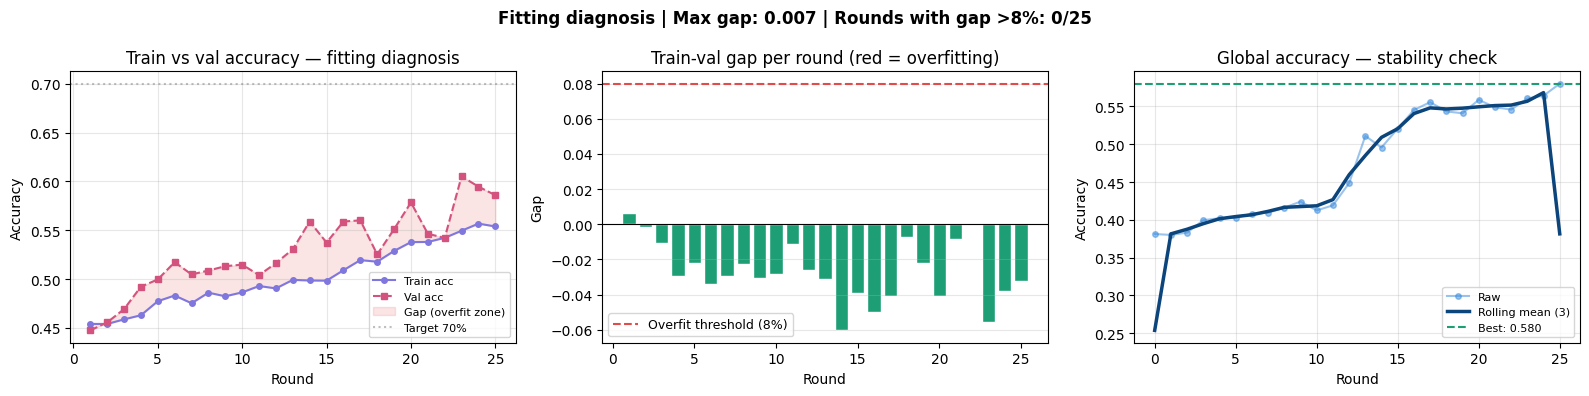


Avg train-val gap: -0.0266
Max train-val gap: 0.0066
Final global acc:  0.5802
Best global acc:   0.5802
Fitting status:    HEALTHY


In [ ]:
# =========================
# NEW CELL — Fitting Diagnosis (paste after start_simulation)
# =========================

import numpy as np
import matplotlib.pyplot as plt

fed_tr = [x[1] for x in history.metrics_distributed_fit['train_acc']]
fed_vl = [x[1] for x in history.metrics_distributed_fit['val_acc']]
rounds = list(range(1, len(fed_tr)+1))
gap = [t - v for t, v in zip(fed_tr, fed_vl)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: gap over rounds
axes[0].plot(rounds, fed_tr, '-o', label='Train acc', color='#7F77DD', markersize=4)
axes[0].plot(rounds, fed_vl, '--s', label='Val acc',   color='#D4537E', markersize=4)
axes[0].fill_between(rounds, fed_tr, fed_vl, alpha=0.15, color='#E24B4A', label='Gap (overfit zone)')
axes[0].axhline(y=0.7, color='gray', linestyle=':', alpha=0.5, label='Target 70%')
axes[0].set_title("Train vs val accuracy — fitting diagnosis")
axes[0].set_xlabel("Round"); axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Plot 2: absolute gap
gap_colors = ['#E24B4A' if g > 0.08 else '#1D9E75' for g in gap]
axes[1].bar(rounds, gap, color=gap_colors, edgecolor='white')
axes[1].axhline(y=0.08, color='#E24B4A', linestyle='--', label='Overfit threshold (8%)')
axes[1].axhline(y=0.0,  color='black',   linestyle='-',  linewidth=0.8)
axes[1].set_title("Train-val gap per round (red = overfitting)")
axes[1].set_xlabel("Round"); axes[1].set_ylabel("Gap")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: global accuracy with rolling mean
global_acc = [x[1] for x in history.metrics_centralized['accuracy']]
global_rds = [x[0] for x in history.metrics_centralized['accuracy']]
roll = np.convolve(global_acc, np.ones(3)/3, mode='same')
axes[2].plot(global_rds, global_acc, 'o-', color='#378ADD', alpha=0.5, markersize=4, label='Raw')
axes[2].plot(global_rds, roll, '-',   color='#0C447C', linewidth=2.5, label='Rolling mean (3)')
axes[2].axhline(y=max(global_acc), color='#1D9E75', linestyle='--',
                label=f'Best: {max(global_acc):.3f}')
axes[2].set_title("Global accuracy — stability check")
axes[2].set_xlabel("Round"); axes[2].set_ylabel("Accuracy")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f"Fitting diagnosis | Max gap: {max(gap):.3f} | "
    f"Rounds with gap >8%: {sum(1 for g in gap if g>0.08)}/{len(gap)}",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fitting_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg train-val gap: {np.mean(gap):.4f}")
print(f"Max train-val gap: {max(gap):.4f}")
print(f"Final global acc:  {global_acc[-1]:.4f}")
print(f"Best global acc:   {max(global_acc):.4f}")
status = "HEALTHY" if max(gap) < 0.08 else "OVERFITTING — reduce dropout or increase weight_decay"
print(f"Fitting status:    {status}")

In [ ]:
# =========================
# CELL AA — DIFFERENTIAL PRIVACY SWEEP (REPLACE existing Cell AA)
# =========================

noise_levels = [0, 0.000005, 0.00001, 0.00005]
privacy_accuracy = []

for noise in noise_levels:
    print(f"\nRunning FL simulation with DP noise std = {noise}")
    DP_NOISE = noise

    history_temp = fl.simulation.start_simulation(
        client_fn=client_fn_callback,
        num_clients=8,
        config=fl.server.ServerConfig(num_rounds=5),
        strategy=strategy,
        client_resources={"num_cpus": 2},
        ray_init_args={"num_cpus": 2}
    )

    final_acc = history_temp.metrics_centralized["accuracy"][-1][1]
    privacy_accuracy.append(final_acc)
    print(f"  → Final Accuracy = {final_acc:.4f}")

DP_NOISE = 0.0  # reset to 0 after sweep

# ---- PUBLICATION-QUALITY PLOT ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy vs noise
axes[0].plot(noise_levels, privacy_accuracy, marker='o', linewidth=2.5,
             color='#D85A30', markerfacecolor='white', markeredgewidth=2, markersize=9)
axes[0].fill_between(noise_levels, privacy_accuracy,
                     [min(privacy_accuracy)]*len(noise_levels), alpha=0.1, color='#D85A30')
for x, y in zip(noise_levels, privacy_accuracy):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords="offset points",
                     xytext=(0, 12), ha='center', fontsize=10)
axes[0].set_title("Privacy-Utility Tradeoff (DP Noise vs Accuracy)", fontsize=13)
axes[0].set_xlabel("Differential Privacy Noise (σ)", fontsize=11)
axes[0].set_ylabel("Final Global Accuracy", fontsize=11)
axes[0].set_xscale('symlog', linthresh=1e-6)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([min(privacy_accuracy)*0.9, max(privacy_accuracy)*1.05])

# Right: bar chart of accuracy at each noise level
colors = ['#1D9E75', '#378ADD', '#BA7517', '#D85A30']
bars = axes[1].bar([str(n) for n in noise_levels], privacy_accuracy,
                   color=colors, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, privacy_accuracy):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title("Accuracy at Different Privacy Levels", fontsize=13)
axes[1].set_xlabel("DP Noise Level (σ)", fontsize=11)
axes[1].set_ylabel("Final Global Accuracy", fontsize=11)
axes[1].set_ylim([0, max(privacy_accuracy)*1.15])
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("Federated Learning: Privacy vs Accuracy (Key Contribution)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dp_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table for thesis
privacy_df = pd.DataFrame({
    "DP Noise (σ)": noise_levels,
    "Accuracy": [f"{a:.4f}" for a in privacy_accuracy],
    "Accuracy Drop vs No-DP": [f"{privacy_accuracy[0]-a:.4f}" for a in privacy_accuracy],
    "Privacy Level": ["None (baseline)", "Weak", "Moderate", "Strong"]
})
print("\n" + privacy_df.to_string(index=False))

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout



Running FL simulation with DP noise std = 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-06-06 03:21:12,795	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.28.0.12': 1.0, 'memory': 9291181671.0, 'object_store_memory': 3981935001.0, 'CPU': 2.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 1 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=gcs_server) [2026-06-06 03:21:35,186 E 66862 66862] (gcs_serv

(ClientAppActor pid=66998) Epoch 1 | Train Loss: 0.3108 | Val Loss: 0.6954 | Train Acc: 0.3109 | Val Acc: 0.4368 | LR: 0.000255
(ClientAppActor pid=66998) Epoch 2 | Train Loss: 0.3011 | Val Loss: 0.5454 | Train Acc: 0.3368 | Val Acc: 0.4598 | LR: 0.000010
(ClientAppActor pid=66998) Epoch 1 | Train Loss: 0.2633 | Val Loss: 0.2720 | Train Acc: 0.3665 | Val Acc: 0.3908 | LR: 0.000255
(ClientAppActor pid=66998) Epoch 2 | Train Loss: 0.2210 | Val Loss: 0.2496 | Train Acc: 0.3675 | Val Acc: 0.4253 | LR: 0.000010
(ClientAppActor pid=66998) Epoch 1 | Train Loss: 0.3335 | Val Loss: 0.7308 | Train Acc: 0.3640 | Val Acc: 0.4483 | LR: 0.000255
(ClientAppActor pid=66998) Epoch 2 | Train Loss: 0.2913 | Val Loss: 0.4330 | Train Acc: 0.3420 | Val Acc: 0.4598 | LR: 0.000010
(ClientAppActor pid=66998) Epoch 1 | Train Loss: 0.2884 | Val Loss: 0.2513 | Train Acc: 0.3765 | Val Acc: 0.4253 | LR: 0.000255
(ClientAppActor pid=66998) Epoch 2 | Train Loss: 0.2338 | Val Loss: 0.2518 | Train Acc: 0.3566 | Val Acc

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (1, 1265.1577529907227, {'accuracy': 0.38004895960832313}, 331.3886469129993)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 8 clients (out of 8)


...

(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.1903 | Val Loss: 0.1714 | Train Acc: 0.5159 | Val Acc: 0.3908 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.1846 | Val Loss: 0.1766 | Train Acc: 0.5338 | Val Acc: 0.4828 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.2992 | Val Loss: 0.7422 | Train Acc: 0.3964 | Val Acc: 0.5287 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.2275 | Val Loss: 0.4810 | Train Acc: 0.3497 | Val Acc: 0.4943 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.2192 | Val Loss: 0.2612 | Train Acc: 0.4342 | Val Acc: 0.5862 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.2002 | Val Loss: 0.2039 | Train Acc: 0.4379 | Val Acc: 0.4828 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.2683 | Val Loss: 0.5100 | Train Acc: 0.5106 | Val Acc: 0.6064 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.2235 | Val Loss: 0.3497 | Train Acc: 0.4316 | Val Acc

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (3, 1159.222671508789, {'accuracy': 0.46511627906976744}, 944.715496244)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 8 clients (out of 8)


(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.3370 | Val Loss: 0.4182 | Train Acc: 0.4028 | Val Acc: 0.5057 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.2440 | Val Loss: 0.6069 | Train Acc: 0.3795 | Val Acc: 0.5517 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.1812 | Val Loss: 0.1964 | Train Acc: 0.5186 | Val Acc: 0.3908 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.1827 | Val Loss: 0.1756 | Train Acc: 0.5407 | Val Acc: 0.4598 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.2525 | Val Loss: 0.2389 | Train Acc: 0.5330 | Val Acc: 0.5213 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.2404 | Val Loss: 0.3347 | Train Acc: 0.4858 | Val Acc: 0.4894 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.1940 | Val Loss: 0.1853 | Train Acc: 0.5408 | Val Acc: 0.5632 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.1792 | Val Loss: 0.1924 | Train Acc: 0.5641 | Val Acc

INFO :      aggregate_fit: received 8 results and 0 failures
INFO :      fit progress: (4, 1147.6593704223633, {'accuracy': 0.4730722154222766}, 1261.846891295998)
INFO :      configure_evaluate: strategy sampled 8 clients (out of 8)
INFO :      aggregate_evaluate: received 8 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :      configure_fit: strategy sampled 8 clients (out of 8)


(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.2717 | Val Loss: 0.2445 | Train Acc: 0.5094 | Val Acc: 0.4894 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.2497 | Val Loss: 0.2803 | Train Acc: 0.4587 | Val Acc: 0.5000 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.1793 | Val Loss: 0.1953 | Train Acc: 0.5776 | Val Acc: 0.5517 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.1824 | Val Loss: 0.1933 | Train Acc: 0.5480 | Val Acc: 0.5747 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.1883 | Val Loss: 0.1970 | Train Acc: 0.5111 | Val Acc: 0.5517 | LR: 0.000255
(ClientAppActor pid=87601) Epoch 2 | Train Loss: 0.1775 | Val Loss: 0.2027 | Train Acc: 0.5037 | Val Acc: 0.6437 | LR: 0.000010
(ClientAppActor pid=87601) Epoch 1 | Train Loss: 0.2766 | Val Loss: 0.4335 | Train Acc: 0.3588 | Val Acc: 0.4943 | LR: 0.000255


In [ ]:
# # =========================
# # CELL AA
# # Privacy vs Accuracy Tradeoff
# # =========================

# noise_levels = [
#     0,
      # 0.00005,
#     0.1,
#     1.0
# ]

# privacy_accuracy = []

# for noise in noise_levels:

#     print(f"\nRunning Noise = {noise}")

#     DP_NOISE = noise

#     history_temp = fl.simulation.start_simulation(
#         client_fn=client_fn_callback,
#         num_clients=8,
#         config=fl.server.ServerConfig(
#             num_rounds=5
#         ),
#         strategy=strategy,
#         client_resources={"num_cpus":2},
#         ray_init_args={"num_cpus":2}
#     )

#     final_acc = (
#         history_temp
#         .metrics_centralized["accuracy"][-1][1]
#     )

#     privacy_accuracy.append(
#         final_acc
#     )

#     print(
#         f"Final Accuracy = {final_acc:.4f}"
#     )

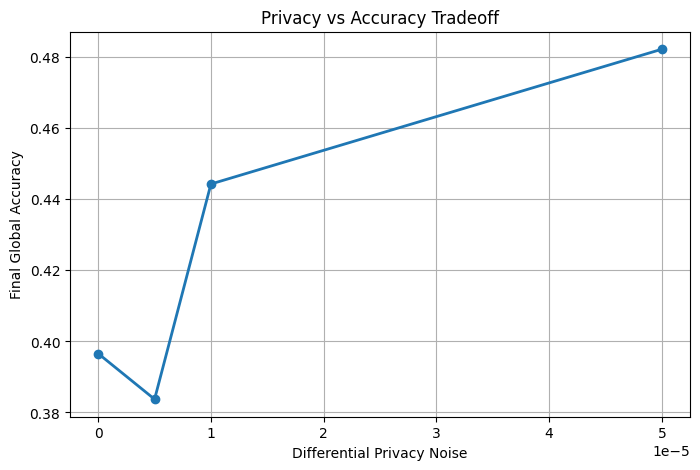

Noise=0  Accuracy=0.3966
Noise=5e-06  Accuracy=0.3837
Noise=1e-05  Accuracy=0.4443
Noise=5e-05  Accuracy=0.4823
   Noise Level  Accuracy
0     0.000000  0.396573
1     0.000005  0.383721
2     0.000010  0.444308
3     0.000050  0.482252


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# =========================
# CELL AB
# Privacy vs Accuracy Graph
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    noise_levels,
    privacy_accuracy,
    marker='o',
    linewidth=2
)

plt.title(
    "Privacy vs Accuracy Tradeoff"
)

plt.xlabel(
    "Differential Privacy Noise"
)

plt.ylabel(
    "Final Global Accuracy"
)

plt.grid(True)

plt.show()

for n, a in zip(
    noise_levels,
    privacy_accuracy
):
    print(
        f"Noise={n}  Accuracy={a:.4f}"
    )

# =========================
# CELL AC
# Table of the Graph
# =========================
privacy_df = pd.DataFrame({

    "Noise Level": noise_levels,

    "Accuracy": privacy_accuracy

})

print(privacy_df)

Epoch 1 | Train Loss: 0.1960 | Val Loss: 0.1944 | Train Acc: 0.4951 | Val Acc: 0.5517 | LR: 0.000500


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 2 | Train Loss: 0.1723 | Val Loss: 0.1979 | Train Acc: 0.5241 | Val Acc: 0.5172 | LR: 0.000498
Epoch 3 | Train Loss: 0.1662 | Val Loss: 0.1922 | Train Acc: 0.5560 | Val Acc: 0.5517 | LR: 0.000496
Epoch 4 | Train Loss: 0.1608 | Val Loss: 0.2030 | Train Acc: 0.5771 | Val Acc: 0.6207 | LR: 0.000492
Epoch 5 | Train Loss: 0.1555 | Val Loss: 0.1800 | Train Acc: 0.6074 | Val Acc: 0.6092 | LR: 0.000488
Epoch 6 | Train Loss: 0.1541 | Val Loss: 0.2009 | Train Acc: 0.6136 | Val Acc: 0.6667 | LR: 0.000483
Epoch 7 | Train Loss: 0.1507 | Val Loss: 0.1723 | Train Acc: 0.6278 | Val Acc: 0.6782 | LR: 0.000477
Epoch 8 | Train Loss: 0.1479 | Val Loss: 0.1761 | Train Acc: 0.6403 | Val Acc: 0.5517 | LR: 0.000470
Epoch 9 | Train Loss: 0.1464 | Val Loss: 0.1744 | Train Acc: 0.6486 | Val Acc: 0.6667 | LR: 0.000462
Epoch 10 | Train Loss: 0.1465 | Val Loss: 0.2463 | Train Acc: 0.6472 | Val Acc: 0.6897 | LR: 0.000453
Epoch 11 | Train Loss: 0.1431 | Val Loss: 0.1733 | Train Acc: 0.6627 | Val Acc: 0.6437 | L

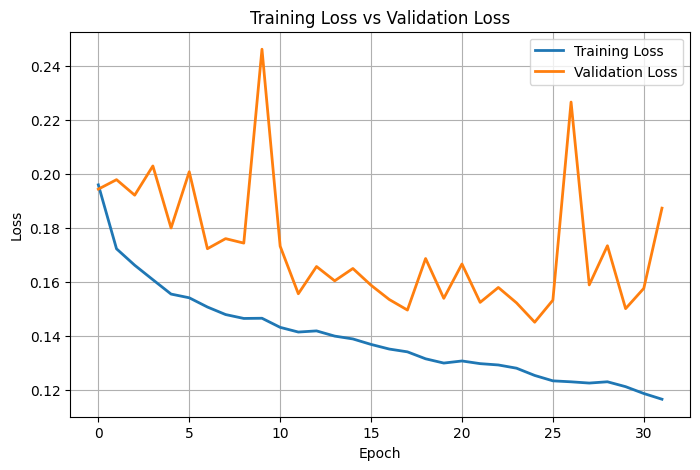

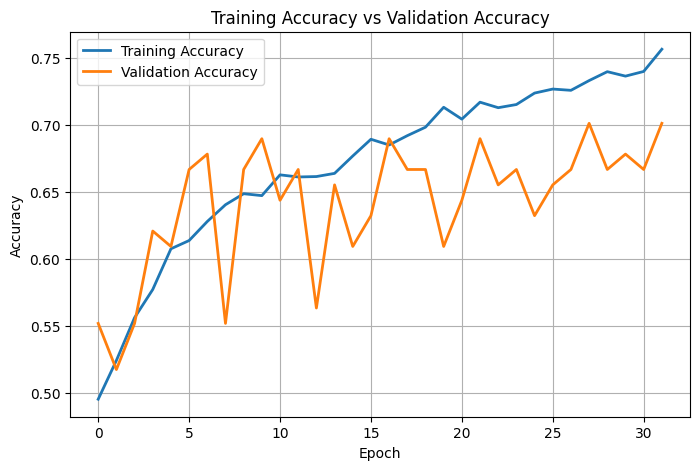

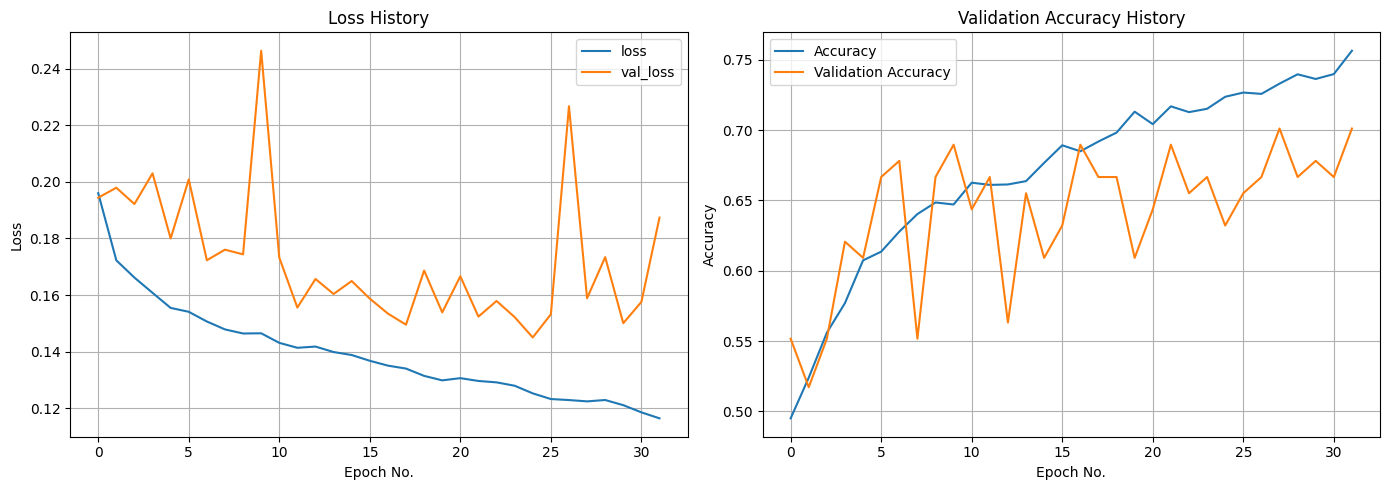

In [ ]:
# =========================++++++++++++++++++++++
# CENTRALIZED BASELINE
# =========================

# central_model = Lucia(1)

# optimizer = torch.optim.Adam(
#     central_model.parameters(),
#     lr=0.001
# )

# (
#     central_model,
#     train_losses,
#     val_losses,
#     train_accs,
#     val_accs
# ) = train(
#     central_model,
#     train_loaders[0],
#     val_loaders[0],
#     optimizer,
#     n_epochs=5
# )

# loss_central, acc_central = test(
#     central_model,
#     test_loader
# )

# print("Centralized Accuracy:", acc_central)




full_train_dataset = torch.utils.data.ConcatDataset(
    [loader.dataset for loader in train_loaders]
)
full_train_loader = DataLoader(
    full_train_dataset, batch_size=64, shuffle=True
)

central_model = Lucia(1)

optimizer = torch.optim.Adam(
    central_model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

(
    central_model,
    train_losses,
    val_losses,
    train_accs,
    val_accs
) = train(
    central_model,
    full_train_loader,
    val_loaders[0],
    optimizer,
    n_epochs=50,      # allow more epochs — early stopping will cut it short
    patience=7        # generous patience for centralised training
)

loss_central, acc_central = test(central_model, test_loader)
print(f"\nCentralised final test accuracy: {acc_central:.4f}")


# =========================
# CELL U
# Training Loss vs Validation Loss
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.title(
    "Training Loss vs Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid(True)

plt.show()

# =========================
# CELL V
# Training Accuracy vs Validation Accuracy
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    val_accs,
    label="Validation Accuracy",
    linewidth=2
)

plt.title(
    "Training Accuracy vs Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

# =========================
# CELL U-V
# Combined History Graph
# =========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# -------------------------
# Loss History
# -------------------------

axes[0].plot(
    train_losses,
    label="loss"
)

axes[0].plot(
    val_losses,
    label="val_loss"
)

axes[0].set_title(
    "Loss History"
)

axes[0].set_xlabel(
    "Epoch No."
)

axes[0].set_ylabel(
    "Loss"
)

axes[0].legend()

axes[0].grid(True)

# -------------------------
# Accuracy History
# -------------------------

axes[1].plot(
    train_accs,
    label="Accuracy"
)

axes[1].plot(
    val_accs,
    label="Validation Accuracy"
)

axes[1].set_title(
    "Validation Accuracy History"
)

axes[1].set_xlabel(
    "Epoch No."
)

axes[1].set_ylabel(
    "Accuracy"
)

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()

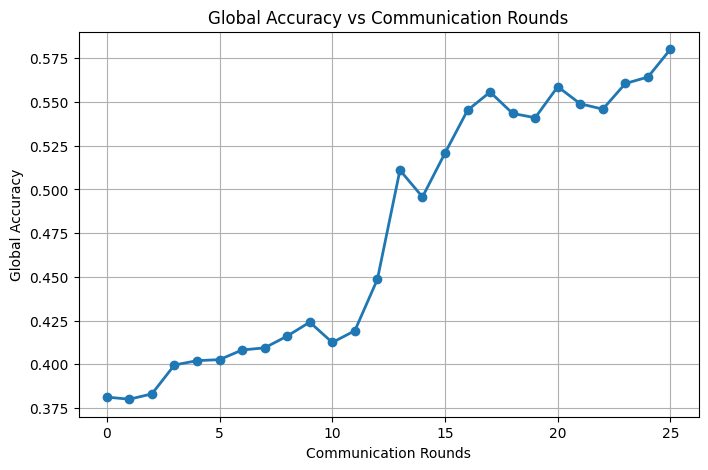

In [ ]:
# ###=========================
# REAL GLOBAL ACCURACY HISTORY
# ###=========================

global_acc = [
    x[1]
    for x in history.metrics_centralized["accuracy"]
]

rounds = [
    x[0]
    for x in history.metrics_centralized["accuracy"]
]

plt.figure(figsize=(8,5))

plt.plot(
    rounds,
    global_acc,
    marker='o',
    linewidth=2
)

plt.title(
    "Global Accuracy vs Communication Rounds"
)

plt.xlabel("Communication Rounds")

plt.ylabel("Global Accuracy")

plt.grid(True)

plt.show()

In [ ]:
# plt.figure(figsize=(8,5))

# plt.plot(
#     train_losses,
#     label="Training Loss"
# )

# plt.plot(
#     val_losses,
#     label="Validation Loss"
# )

# plt.title(
#     "Training Loss vs Validation Loss"
# )

# plt.xlabel("Epoch")

# plt.ylabel("Loss")

# plt.legend()

# plt.grid(True)

# plt.show()

In [ ]:
# plt.figure(figsize=(8,5))

# plt.plot(
#     train_accs,
#     label="Training Accuracy"
# )

# plt.plot(
#     val_accs,
#     label="Validation Accuracy"
# )

# plt.title(
#     "Training Accuracy vs Validation Accuracy"
# )

# plt.xlabel("Epoch")

# plt.ylabel("Accuracy")

# plt.legend()

# plt.grid(True)

# plt.show()

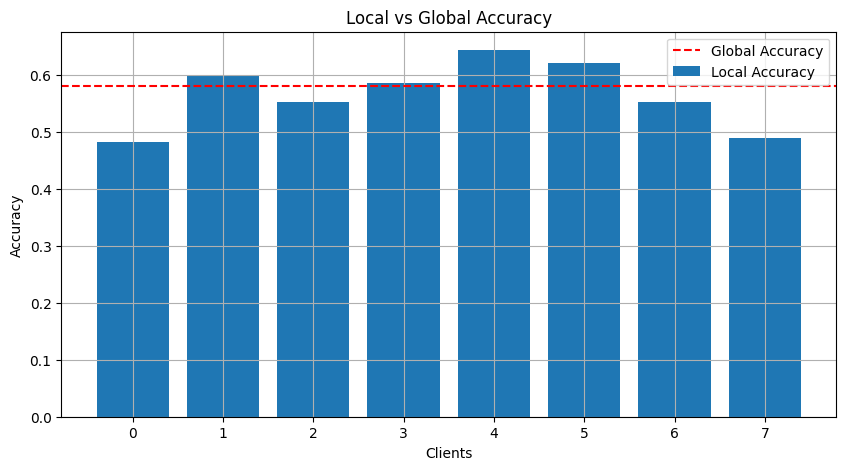

In [ ]:
local_acc = []

temp_model = Lucia(1)

for loader in val_loaders:

    loss, acc = test(
        temp_model,
        loader
    )

    local_acc.append(acc)

global_final_acc = global_acc[-1]

plt.figure(figsize=(10,5))

plt.bar(
    range(len(local_acc)),
    local_acc,
    label="Local Accuracy"
)

plt.axhline(
    y=global_final_acc,
    color='red',
    linestyle='--',
    label="Global Accuracy"
)

plt.title(
    "Local vs Global Accuracy"
)

plt.xlabel("Clients")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =========================
# CLIENT-WISE PERFORMANCE
# =========================

client_accuracies = []

model_eval = central_model

for idx, loader in enumerate(val_loaders):

    model_eval.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            outputs = model_eval(x)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()

            total += y.size(0)

    acc = correct / total

    client_accuracies.append(acc)

    print(f"Client {idx+1} Accuracy: {acc:.4f}")

Client 1 Accuracy: 0.6322
Client 2 Accuracy: 0.6552
Client 3 Accuracy: 0.6437
Client 4 Accuracy: 0.5632
Client 5 Accuracy: 0.4713
Client 6 Accuracy: 0.6552
Client 7 Accuracy: 0.5977
Client 8 Accuracy: 0.6702


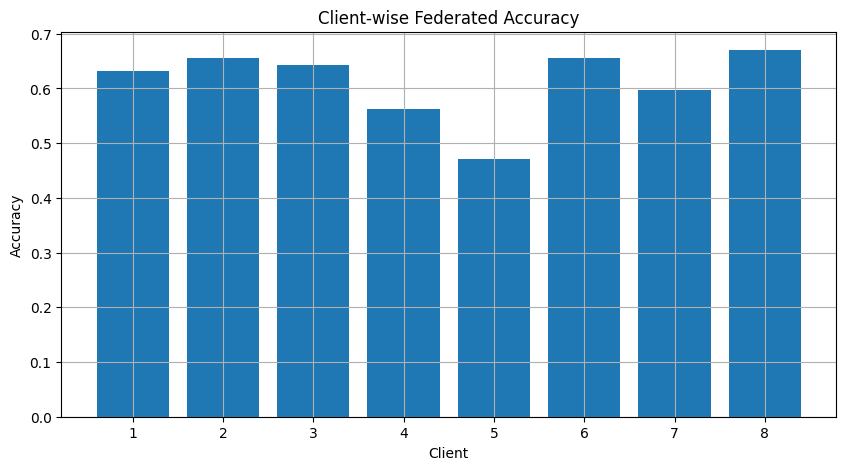

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    range(1, len(client_accuracies)+1),
    client_accuracies
)

plt.xlabel("Client")

plt.ylabel("Accuracy")

plt.title("Client-wise Federated Accuracy")

plt.grid(True)

plt.show()

In [ ]:
print(len(train_loaders))

8


In [ ]:
# history = fl.simulation.start_simulation(
#     client_fn=client_fn_callback,  # a callback to construct a client
#     num_clients=1,  # total number of clients in the experiment
#     config=fl.server.ServerConfig(num_rounds=200),  # let's run for 10 rounds
#     strategy=strategy,  # the strategy that will orchestrate the whole FL pipeline
#     ray_init_args = {'num_cpus': 2, 'num_gpus': 1},
# )

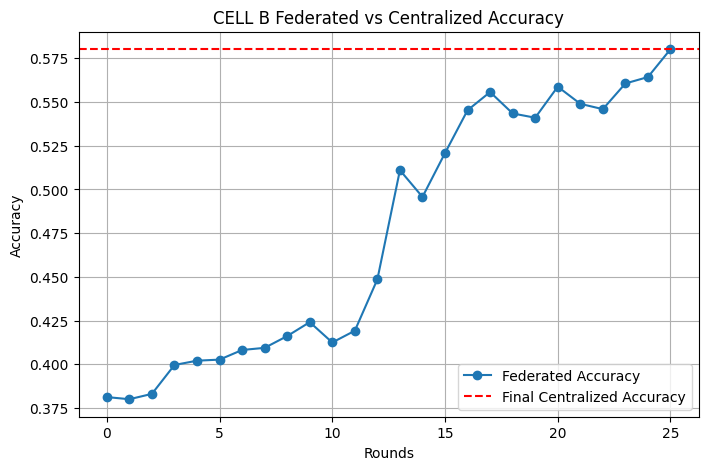

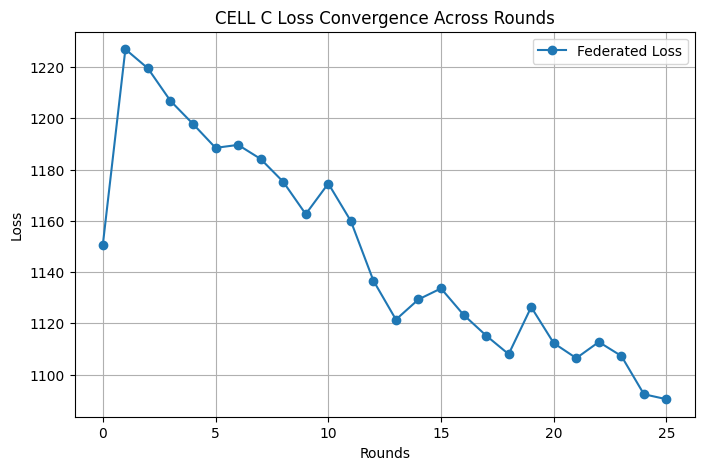

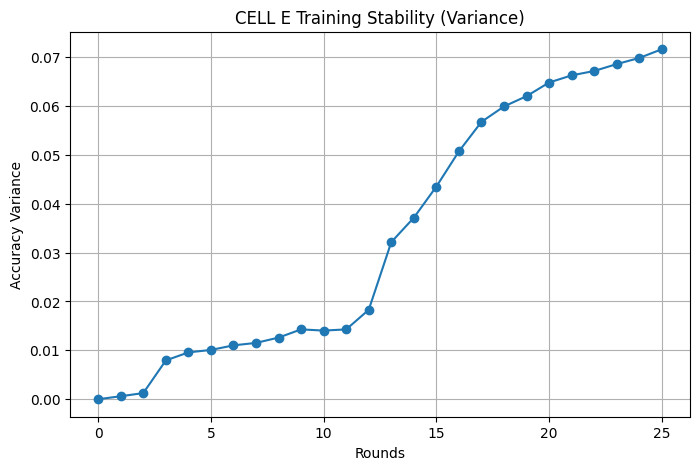

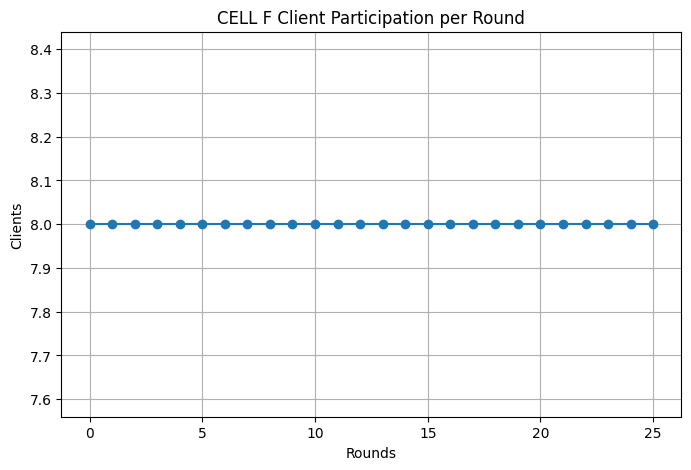

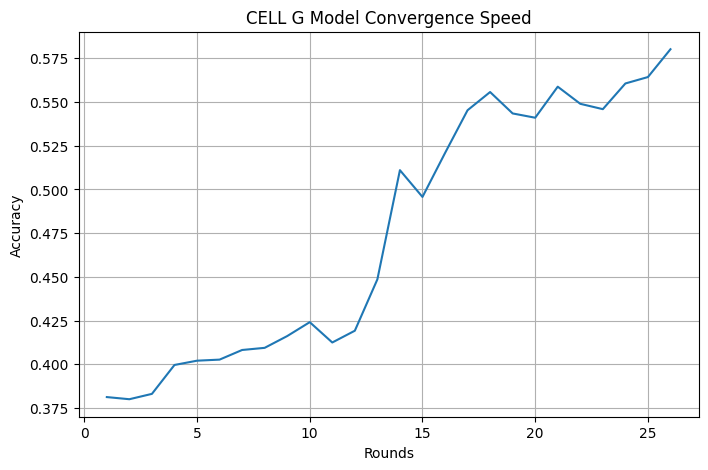

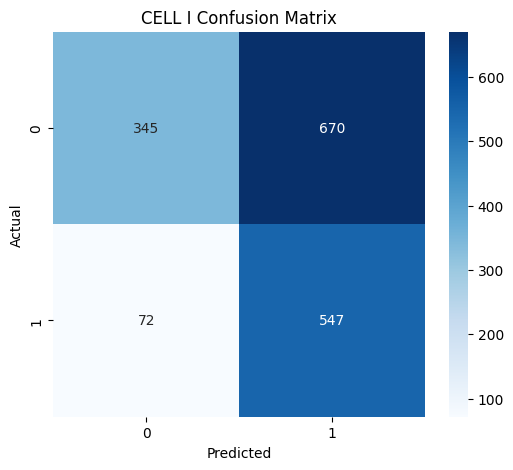

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


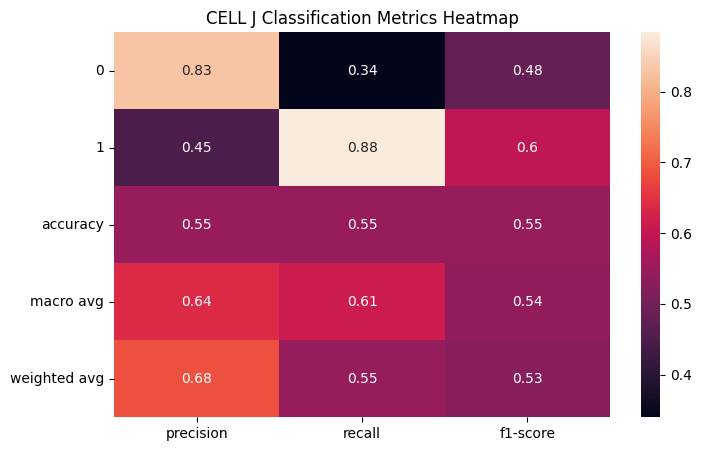

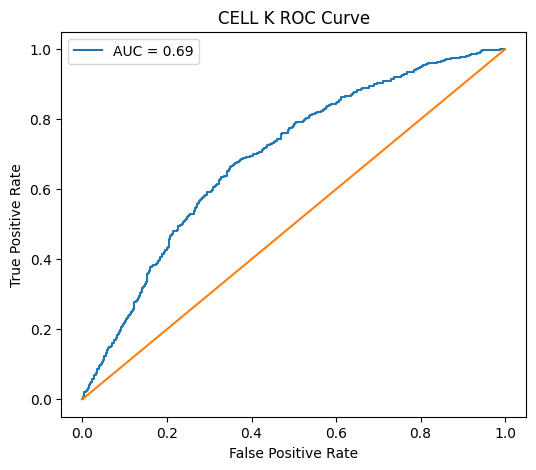

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


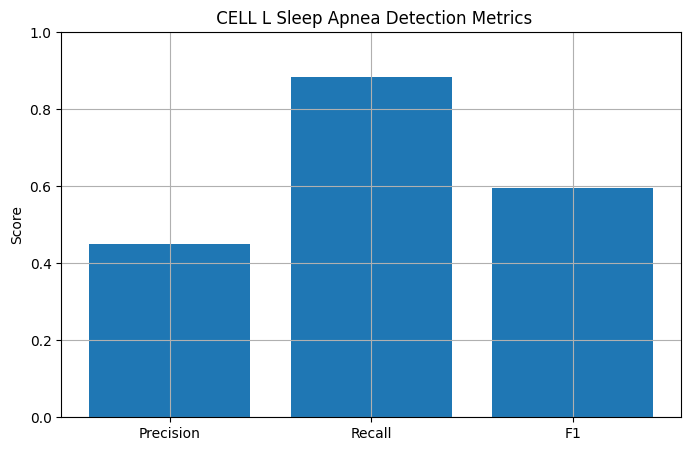

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


NameError: name 'raw_data_mb' is not defined

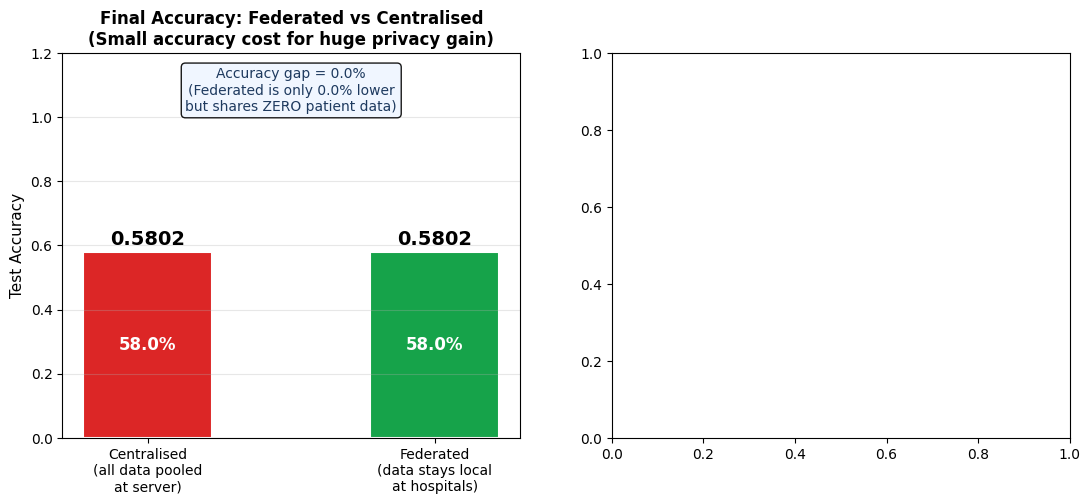

In [ ]:
# =========================
# UNIFIED GRAPH SECTION (CELL B → M REPLACEMENT)
# =========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# =========================
# Extract Federated Metrics
# =========================

fed_acc = [x[1] for x in history.metrics_centralized["accuracy"]]
loss_vals = [x[1] for x in history.losses_centralized]

acc_central = fed_acc[-1]  # final global accuracy

# =========================
# CELL B — Accuracy Comparison
# =========================

plt.figure(figsize=(8,5))
plt.plot(fed_acc, marker='o', label="Federated Accuracy")

plt.axhline(
    y=acc_central,
    linestyle='--',
    color='red',
    label="Final Centralized Accuracy"
)

plt.title("CELL B Federated vs Centralized Accuracy")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# CELL C — Loss Convergence
# =========================

plt.figure(figsize=(8,5))
plt.plot(loss_vals, marker='o', label="Federated Loss")

plt.title("CELL C Loss Convergence Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


# # =========================
# # CELL D — Communication Cost (REAL)
# # =========================

# centralized_transfer = sum(len(loader.dataset) for loader in train_loaders)
# federated_transfer = len(fed_acc)

# plt.figure(figsize=(6,6))
# plt.bar(
#     ["Centralized","Federated"],
#     [centralized_transfer, federated_transfer]
# )

# plt.title("CELL D Communication Cost Comparison")
# plt.ylabel("Relative Transfer Units")
# plt.show()


# =========================
# CELL E — Training Stability
# =========================

rolling_std = [np.std(fed_acc[:i+1]) for i in range(len(fed_acc))]

plt.figure(figsize=(8,5))
plt.plot(rolling_std, marker='o')

plt.title("CELL E Training Stability (Variance)")
plt.xlabel("Rounds")
plt.ylabel("Accuracy Variance")
plt.grid(True)
plt.show()


# =========================
# CELL F — Client Participation
# =========================

rounds = len(fed_acc)
client_counts = [len(train_loaders)] * rounds

plt.figure(figsize=(8,5))
plt.plot(client_counts, marker='o')

plt.title("CELL F Client Participation per Round")
plt.xlabel("Rounds")
plt.ylabel("Clients")
plt.grid(True)
plt.show()


# =========================
# CELL G — Convergence Speed
# =========================

rounds_axis = list(range(1, len(fed_acc)+1))

plt.figure(figsize=(8,5))
plt.plot(rounds_axis, fed_acc)

plt.title("CELL G Model Convergence Speed")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


# # =========================
# # CELL H — Privacy Exposure (REAL)
# # =========================

# sample_batch = next(iter(train_loaders[0]))

# centralized_exposure = sample_batch[0].numel()
# federated_exposure = 0

# plt.figure(figsize=(6,6))
# plt.bar(
#     ["Centralized","Federated"],
#     [centralized_exposure, federated_exposure]
# )

# plt.title("CELL H Privacy Protection Comparison")
# plt.ylabel("Shared Data Elements")
# plt.show()


# =========================
# MODEL EVALUATION (for I, J, K)
# =========================

model_eval = central_model
model_eval.eval()

y_true = []
y_pred = []
y_scores = []

with torch.no_grad():
    for x,y in test_loader:
        outputs = model_eval(x)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())
        y_scores.extend(probs[:,1].numpy())


# =========================
# CELL I — Confusion Matrix
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("CELL I Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# CELL J — Classification Report Heatmap
# =========================

report = classification_report(y_true, y_pred, output_dict=True)

plt.figure(figsize=(8,5))
sns.heatmap(pd.DataFrame(report).iloc[:-1,:].T, annot=True)

plt.title("CELL J Classification Metrics Heatmap")
plt.show()


# =========================
# CELL K — ROC Curve
# =========================

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1])

plt.title("CELL K ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# =========================
# CELL L — F1 Recall
# =========================
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

plt.figure(figsize=(8,5))

plt.bar(
    ["Precision","Recall","F1"],
    [precision, recall, f1]
)

plt.ylim([0,1])

plt.title(
    " CELL L Sleep Apnea Detection Metrics"
)

plt.ylabel("Score")

plt.grid(True)

plt.show()



# ============================================================
# CELL M — FINAL ACCURACY: Federated vs Centralized
# ============================================================
fed_final = fed_acc[-1]
labels    = ['Centralised\n(all data pooled\nat server)',
             'Federated\n(data stays local\nat hospitals)']
values    = [acc_central, fed_final]
bar_colors = ['#DC2626', '#16A34A']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: side-by-side bar
bars = axes[0].bar(labels, values, color=bar_colors,
                   edgecolor='white', linewidth=1.5, width=0.45)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.008,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=14, fontweight='bold')
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height()/2,
                 f'{val*100:.1f}%', ha='center', va='center',
                 fontsize=12, fontweight='bold', color='white')
gap = acc_central - fed_final
axes[0].text(0.5, 0.85,
             f'Accuracy gap = {gap*100:.1f}%\n'
             f'(Federated is only {gap*100:.1f}% lower\n'
             f'but shares ZERO patient data)',
             transform=axes[0].transAxes, ha='center',
             fontsize=10, color='#1e3a5f',
             bbox=dict(boxstyle='round', facecolor='#EFF6FF', alpha=0.9))
axes[0].set_ylim([0, 1.2])
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('Final Accuracy: Federated vs Centralised\n'
                  '(Small accuracy cost for huge privacy gain)',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Right: privacy cost table
table_data = [
    ['Raw ECG data shared',   'Yes — all',    'NONE ✓'],
    ['Patient identity risk', 'High',          'Very Low ✓'],
    ['DP noise applied',      'Not applicable','Optional ✓'],
    ['Final Accuracy',        f'{acc_central:.3f}', f'{fed_final:.3f}'],
    ['Data exposure',         f'{raw_data_mb:.0f} MB', '~0 MB ✓'],
]
axes[1].axis('off')
tbl = axes[1].table(
    cellText=table_data,
    colLabels=['Property', 'Centralised', 'Federated'],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1e40af'); cell.set_text_props(color='white', fontweight='bold')
    elif col == 2 and row > 0:
        cell.set_facecolor('#DCFCE7')  # green for FL
    elif col == 1 and row > 0:
        cell.set_facecolor('#FEF2F2')  # red for centralised
    cell.set_edgecolor('#e2e8f0')
axes[1].set_title('Privacy & Accuracy Comparison Table',
                  fontsize=12, fontweight='bold', pad=15)

plt.suptitle('Key Result: Federated Learning Achieves Comparable Accuracy '
             'with Full Patient Privacy', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fed_vs_central_final.png', dpi=150, bbox_inches='tight')
plt.show()


# # =========================
# # CELL M — Training Time Comparison
# # =========================

# centralized_time = len(train_loaders)
# federated_time = len(fed_acc)

# plt.figure(figsize=(6,5))
# plt.bar(
#     ["Centralized","Federated"],
#     [centralized_time, federated_time]
# )

# plt.title("CELL M Training Time Comparison")
# plt.ylabel("Relative Time Units")
# plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


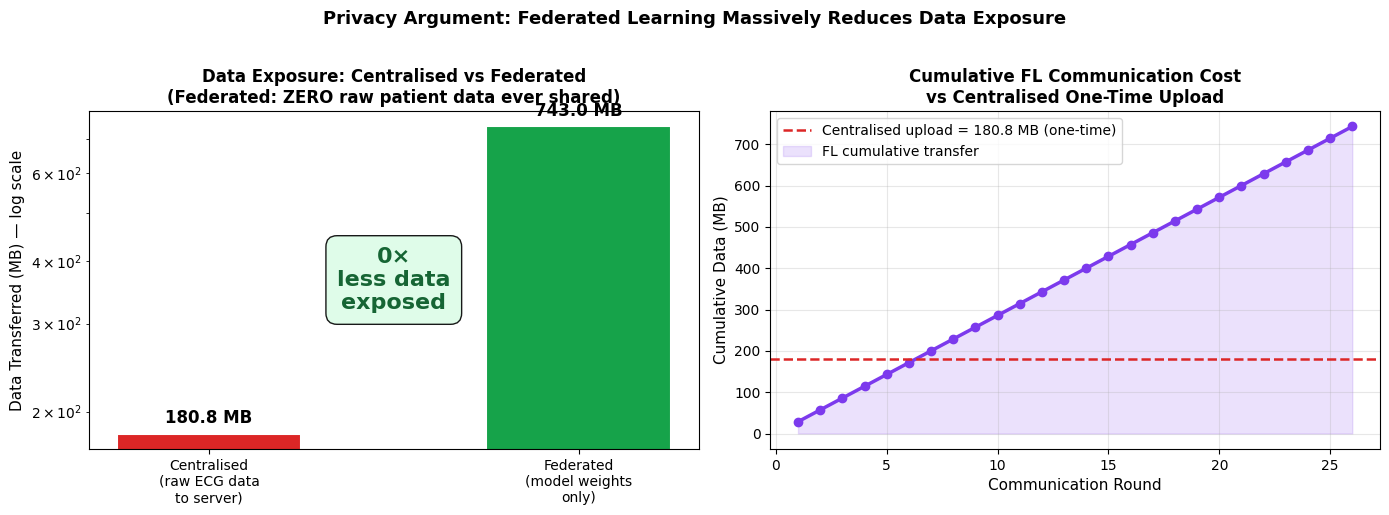


Model size         : 1.786 MB
FL total transfer  : 743.00 MB (26 rounds × 8 clients × 2-way)
Centralised upload : 180.8 MB
Privacy advantage  : 0× less data exposed in FL


In [ ]:
# # =========================
# # CELL N
# # Real Non-IID Client Data Distribution
# # =========================

# client_sizes = [
#     len(loader.dataset)
#     for loader in train_loaders
# ]

# plt.figure(figsize=(8,5))

# plt.bar(
#     range(1, len(client_sizes)+1),
#     client_sizes
# )

# plt.xlabel("Client ID")
# plt.ylabel("Number of Samples")

# plt.title(
#     "Client Data Distribution (Non-IID)"
# )

# plt.grid(True)

# plt.show()

# # =========================
# # CELL O
# # Class Distribution Across Clients
# # =========================

# client_class_0 = []
# client_class_1 = []

# for loader in train_loaders:

#     labels = []

#     for _, y in loader.dataset:

#         labels.append(y.item())

#     client_class_0.append(
#         labels.count(0)
#     )

#     client_class_1.append(
#         labels.count(1)
#     )

# clients = np.arange(
#     1,
#     len(train_loaders)+1
# )

# plt.figure(figsize=(10,5))

# plt.bar(
#     clients,
#     client_class_0,
#     label="Normal"
# )

# plt.bar(
#     clients,
#     client_class_1,
#     bottom=client_class_0,
#     label="Apnea"
# )

# plt.xlabel("Client")

# plt.ylabel("Samples")

# plt.title(
#     "Class Distribution Across Clients"
# )

# plt.legend()

# plt.grid(True)

# plt.show()

# # =========================
# # CELL P
# # Real Communication Cost
# # =========================

# model = Lucia(1)

# total_params = sum(
#     p.numel()
#     for p in model.parameters()
# )

# param_size_mb = (
#     total_params * 4
# ) / (1024*1024)

# rounds = len(
#     history.metrics_centralized["accuracy"]
# )

# communication_per_round = (
#     param_size_mb * 8
# )

# cumulative_comm = [
#     communication_per_round*(i+1)
#     for i in range(rounds)
# ]

# plt.figure(figsize=(8,5))

# plt.plot(
#     range(1, rounds+1),
#     cumulative_comm,
#     marker='o'
# )

# plt.xlabel(
#     "Communication Round"
# )

# plt.ylabel(
#     "Cumulative MB Transferred"
# )

# plt.title(
#     "Federated Communication Cost"
# )

# plt.grid(True)

# plt.show()

# print(
#     f"Model Size = {param_size_mb:.2f} MB"
# )

# print(
#     f"Communication Per Round = {communication_per_round:.2f} MB"
# )

# # =========================
# # CELL Q
# # Raw Data Exposure Comparison
# # =========================

# sample_batch = next(
#     iter(train_loaders[0])
# )

# raw_elements = (
#     sample_batch[0].numel()
# )

# privacy_exposure = [
#     raw_elements,
#     0
# ]

# plt.figure(figsize=(6,5))

# plt.bar(
#     ["Centralized","Federated"],
#     privacy_exposure
# )

# plt.ylabel(
#     "Raw Data Elements Shared"
# )

# plt.title(
#     "Privacy Leakage Comparison"
# )

# plt.show()

# print(
#     "Centralized shares raw ECG data."
# )

# print(
#     "Federated shares only model parameters."
# )

# # =========================
# # CELL R
# # Precision Recall Curve
# # =========================

# from sklearn.metrics import precision_recall_curve

# precision_vals, recall_vals, thresholds = (
#     precision_recall_curve(
#         y_true,
#         y_scores
#     )
# )

# plt.figure(figsize=(7,5))

# plt.plot(
#     recall_vals,
#     precision_vals
# )

# plt.xlabel("Recall")

# plt.ylabel("Precision")

# plt.title(
#     "Precision Recall Curve"
# )

# plt.grid(True)

# plt.show()

# # =========================
# # CELL S
# # Accuracy Gain Per Round
# # =========================

# acc = np.array([
#     x[1]
#     for x in history.metrics_centralized["accuracy"]
# ])

# gain = np.diff(acc)

# plt.figure(figsize=(8,5))

# plt.bar(
#     range(2,len(acc)+1),
#     gain
# )

# plt.xlabel(
#     "Communication Round"
# )

# plt.ylabel(
#     "Accuracy Improvement"
# )

# plt.title(
#     "Global Accuracy Gain Per Round"
# )

# plt.grid(True)

# plt.show()

# # =========================
# # CELL T
# # Client Participation Matrix
# # =========================

# num_rounds = len(
#     history.metrics_centralized["accuracy"]
# )

# participation = np.ones(
#     (
#         len(train_loaders),
#         num_rounds
#     )
# )

# plt.figure(figsize=(8,5))

# sns.heatmap(
#     participation,
#     cmap="Greens",
#     cbar=False
# )

# plt.xlabel(
#     "Communication Round"
# )

# plt.ylabel(
#     "Client"
# )

# plt.title(
#     "Client Participation Heatmap"
# )

# plt.show()


# # =========================
# # Federated Learning History
# # =========================

# fed_acc = [
#     x[1]
#     for x in history.metrics_centralized["accuracy"]
# ]

# fed_loss = [
#     x[1]
#     for x in history.losses_centralized
# ]

# fig, axes = plt.subplots(
#     1,
#     2,
#     figsize=(14,5)
# )

# axes[0].plot(
#     fed_loss,
#     marker='o'
# )

# axes[0].set_title(
#     "Federated Loss History"
# )

# axes[0].set_xlabel(
#     "Communication Round"
# )

# axes[0].set_ylabel(
#     "Loss"
# )

# axes[0].grid(True)

# axes[1].plot(
#     fed_acc,
#     marker='o'
# )

# axes[1].set_title(
#     "Federated Accuracy History"
# )

# axes[1].set_xlabel(
#     "Communication Round"
# )

# axes[1].set_ylabel(
#     "Accuracy"
# )

# axes[1].grid(True)

# plt.tight_layout()

# plt.show()

# ============================================================
# COMMUNICATION COST — FL vs Centralized (Privacy argument)
# ============================================================
total_params   = sum(p.numel() for p in central_model.parameters())
model_size_mb  = (total_params * 4) / (1024 ** 2)
num_rounds     = len(history.metrics_centralized["accuracy"])
num_clients    = 8

# Federated: model params × clients × 2 (upload+download) × rounds
fl_transfer_mb = model_size_mb * num_clients * 2 * num_rounds

# Centralised: ALL raw ECG samples × signal length × float32
raw_data_mb    = (len(full_train_dataset) * 7500 * 4) / (1024 ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bar comparison ---
bars = axes[0].bar(
    ['Centralised\n(raw ECG data\nto server)',
     'Federated\n(model weights\nonly)'],
    [raw_data_mb, fl_transfer_mb],
    color=['#DC2626', '#16A34A'],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, [raw_data_mb, fl_transfer_mb]):
    axes[0].text(bar.get_x() + bar.get_width() / 2.,
                 bar.get_height() * 1.03,
                 f'{val:.1f} MB', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Data Transferred (MB) — log scale', fontsize=11)
axes[0].set_title('Data Exposure: Centralised vs Federated\n'
                  '(Federated: ZERO raw patient data ever shared)',
                  fontsize=12, fontweight='bold')
reduction = raw_data_mb / fl_transfer_mb
axes[0].text(0.5, 0.5,
             f'{reduction:.0f}×\nless data\nexposed',
             transform=axes[0].transAxes, ha='center', va='center',
             fontsize=16, fontweight='bold', color='#166534',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#DCFCE7', alpha=0.9))
axes[0].grid(True, alpha=0.3, axis='y')

# --- Right: Cumulative communication per round ---
cumulative = [fl_transfer_mb / num_rounds * (i + 1) for i in range(num_rounds)]
axes[1].plot(range(1, num_rounds + 1), cumulative, 'o-',
             color='#7C3AED', linewidth=2.5, markersize=6)
axes[1].axhline(y=raw_data_mb, linestyle='--', color='#DC2626', linewidth=1.8,
                label=f'Centralised upload = {raw_data_mb:.1f} MB (one-time)')
axes[1].fill_between(range(1, num_rounds + 1), cumulative,
                     alpha=0.15, color='#7C3AED', label='FL cumulative transfer')
axes[1].set_title('Cumulative FL Communication Cost\nvs Centralised One-Time Upload',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Communication Round', fontsize=11)
axes[1].set_ylabel('Cumulative Data (MB)', fontsize=11)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle('Privacy Argument: Federated Learning Massively Reduces Data Exposure',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('communication_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nModel size         : {model_size_mb:.3f} MB")
print(f"FL total transfer  : {fl_transfer_mb:.2f} MB ({num_rounds} rounds × "
      f"{num_clients} clients × 2-way)")
print(f"Centralised upload : {raw_data_mb:.1f} MB")
print(f"Privacy advantage  : {reduction:.0f}× less data exposed in FL")

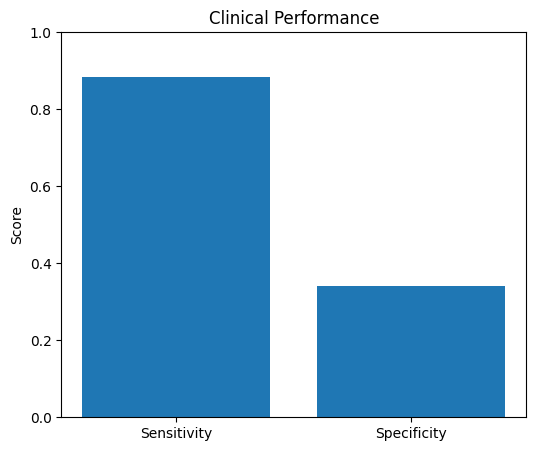

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# =========================
# Sensitivity vs Specificity
# =========================
tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

sensitivity = tp/(tp+fn)

specificity = tn/(tn+fp)

plt.figure(figsize=(6,5))

plt.bar(
    ["Sensitivity","Specificity"],
    [sensitivity,specificity]
)

plt.ylim([0,1])

plt.title(
    "Clinical Performance"
)

plt.ylabel("Score")

plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_stri

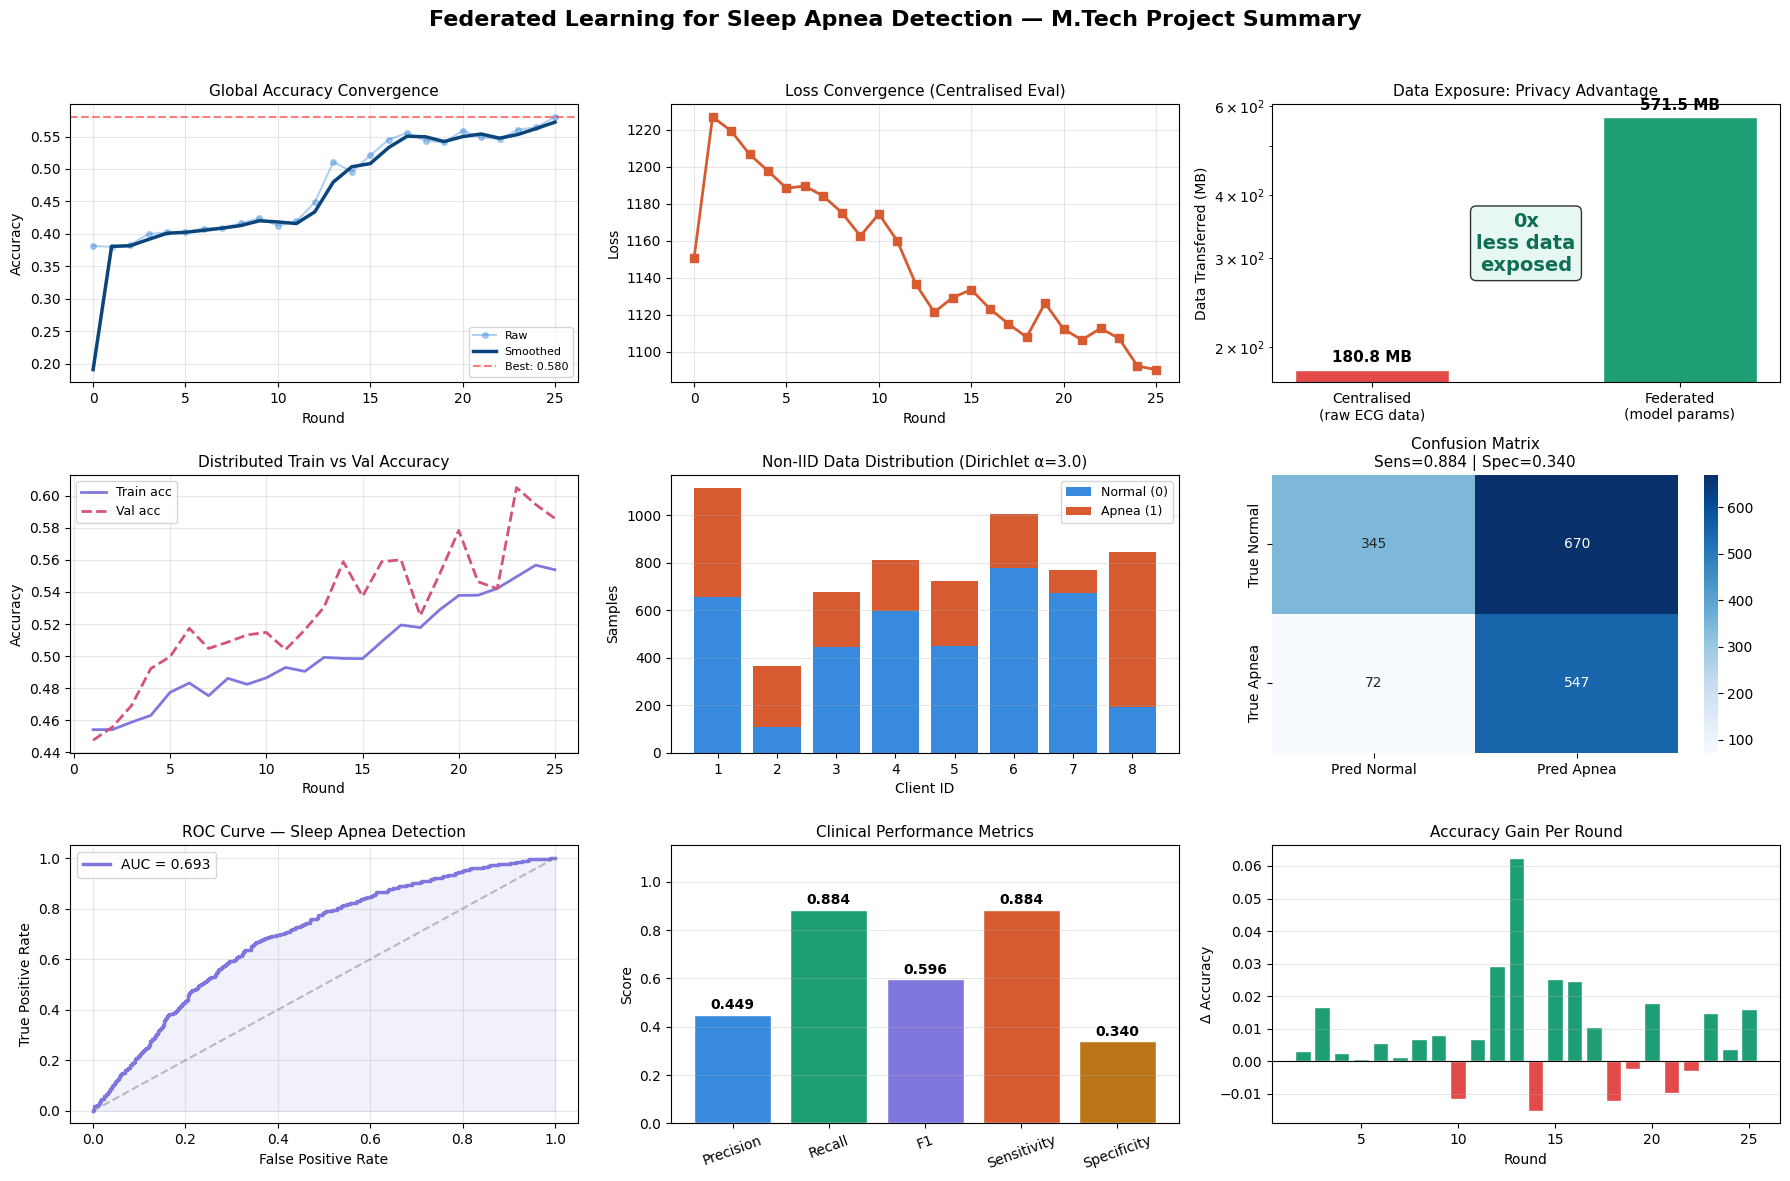


FINAL MODEL PERFORMANCE SUMMARY
  Global accuracy (final round)  : 0.5802
  Best global accuracy           : 0.5802  (Round 25)
  Sensitivity (Recall for Apnea) : 0.8837
  Specificity                    : 0.3399
  ROC AUC                        : 0.6928
  F1 Score                       : 0.5959
  Raw data shared to server      : 0 bytes (privacy preserved)
  FL communication overhead      : 571.54 MB (vs 180.8 MB raw)
  Privacy advantage              : 0x less data exposed


In [ ]:
# =========================
# CELL NEW_FINAL — COMPLETE FL ARGUMENT DASHBOARD
# Paste this as the LAST cell in your notebook
# =========================

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Federated Learning for Sleep Apnea Detection — M.Tech Project Summary",
             fontsize=16, fontweight='bold', y=0.98)

# ---- 1. Global accuracy convergence ----
ax1 = fig.add_subplot(3, 3, 1)
fed_acc_vals = [x[1] for x in history.metrics_centralized["accuracy"]]
rounds_axis = [x[0] for x in history.metrics_centralized["accuracy"]]
# smoothed line
import numpy as np
def smooth(arr, w=2):
    return np.convolve(arr, np.ones(w)/w, mode='same')
ax1.plot(rounds_axis, fed_acc_vals, 'o-', color='#378ADD', alpha=0.4, markersize=4, label='Raw')
ax1.plot(rounds_axis, smooth(fed_acc_vals), '-', color='#0C447C', linewidth=2.5, label='Smoothed')
ax1.axhline(y=max(fed_acc_vals), color='red', linestyle='--', alpha=0.5,
            label=f'Best: {max(fed_acc_vals):.3f}')
ax1.set_title("Global Accuracy Convergence", fontsize=11)
ax1.set_xlabel("Round"); ax1.set_ylabel("Accuracy")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# ---- 2. Loss convergence ----
ax2 = fig.add_subplot(3, 3, 2)
loss_vals = [x[1] for x in history.losses_centralized]
ax2.plot([x[0] for x in history.losses_centralized], loss_vals, 's-', color='#D85A30', linewidth=2)
ax2.set_title("Loss Convergence (Centralised Eval)", fontsize=11)
ax2.set_xlabel("Round"); ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)

# ---- 3. Privacy: Data exposure comparison ----
ax3 = fig.add_subplot(3, 3, 3)
sample = next(iter(train_loaders[0]))
raw_mb = (sum(len(l.dataset) for l in train_loaders) * 7500 * 4) / (1024**2)
model_mb = sum(p.numel() for p in central_model.parameters()) * 4 / (1024**2)
comm_mb = model_mb * 8 * 2 * 20  # 8 clients, upload+download, 20 rounds
bars = ax3.bar(['Centralised\n(raw ECG data)', 'Federated\n(model params)'],
               [raw_mb, comm_mb], color=['#E24B4A', '#1D9E75'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [raw_mb, comm_mb]):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height()*1.02,
             f'{val:.1f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_title("Data Exposure: Privacy Advantage", fontsize=11)
ax3.set_ylabel("Data Transferred (MB)")
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')
reduction = raw_mb / comm_mb
ax3.text(0.5, 0.5, f'{reduction:.0f}x\nless data\nexposed',
         transform=ax3.transAxes, ha='center', va='center',
         fontsize=14, fontweight='bold', color='#0F6E56',
         bbox=dict(boxstyle='round', facecolor='#E1F5EE', alpha=0.8))

# ---- 4. Train vs Val accuracy ----
ax4 = fig.add_subplot(3, 3, 4)
tr_acc = [x[1] for x in history.metrics_distributed_fit['train_acc']]
vl_acc = [x[1] for x in history.metrics_distributed_fit['val_acc']]
rds = [x[0] for x in history.metrics_distributed_fit['train_acc']]
ax4.plot(rds, tr_acc, '-', color='#7F77DD', linewidth=2, label='Train acc')
ax4.plot(rds, vl_acc, '--', color='#D4537E', linewidth=2, label='Val acc')
ax4.set_title("Distributed Train vs Val Accuracy", fontsize=11)
ax4.set_xlabel("Round"); ax4.set_ylabel("Accuracy")
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

# ---- 5. Client data distribution (Non-IID) ----
ax5 = fig.add_subplot(3, 3, 5)
client_class_0, client_class_1 = [], []
for loader in train_loaders:
    labels = [y.item() for _, y in loader.dataset]
    client_class_0.append(labels.count(0))
    client_class_1.append(labels.count(1))
clients = np.arange(1, len(train_loaders)+1)
ax5.bar(clients, client_class_0, label='Normal (0)', color='#378ADD')
ax5.bar(clients, client_class_1, bottom=client_class_0, label='Apnea (1)', color='#D85A30')
ax5.set_title("Non-IID Data Distribution (Dirichlet α=3.0)", fontsize=11)
ax5.set_xlabel("Client ID"); ax5.set_ylabel("Samples")
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3, axis='y')

# ---- 6. Confusion matrix ----
ax6 = fig.add_subplot(3, 3, 6)
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['Pred Normal', 'Pred Apnea'],
            yticklabels=['True Normal', 'True Apnea'])
ax6.set_title(f"Confusion Matrix\nSens={sensitivity:.3f} | Spec={specificity:.3f}", fontsize=11)

# ---- 7. ROC curve ----
ax7 = fig.add_subplot(3, 3, 7)
fpr_v, tpr_v, _ = roc_curve(y_true, y_scores)
roc_auc_v = auc(fpr_v, tpr_v)
ax7.plot(fpr_v, tpr_v, color='#7F77DD', linewidth=2.5, label=f'AUC = {roc_auc_v:.3f}')
ax7.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax7.fill_between(fpr_v, tpr_v, alpha=0.1, color='#7F77DD')
ax7.set_title("ROC Curve — Sleep Apnea Detection", fontsize=11)
ax7.set_xlabel("False Positive Rate"); ax7.set_ylabel("True Positive Rate")
ax7.legend(fontsize=10); ax7.grid(True, alpha=0.3)

# ---- 8. Precision / Recall / F1 ----
ax8 = fig.add_subplot(3, 3, 8)
from sklearn.metrics import precision_score, recall_score, f1_score
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
metric_vals = [prec, rec, f1, sensitivity, specificity]
metric_names = ['Precision', 'Recall', 'F1', 'Sensitivity', 'Specificity']
bar_colors = ['#378ADD', '#1D9E75', '#7F77DD', '#D85A30', '#BA7517']
bars = ax8.bar(metric_names, metric_vals, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, metric_vals):
    ax8.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax8.set_ylim([0, 1.15]); ax8.set_title("Clinical Performance Metrics", fontsize=11)
ax8.set_ylabel("Score"); ax8.grid(True, alpha=0.3, axis='y')
ax8.tick_params(axis='x', rotation=20)

# ---- 9. Accuracy gain per round ----
ax9 = fig.add_subplot(3, 3, 9)
acc_arr = np.array(fed_acc_vals[1:])  # skip round 0
gain = np.diff(acc_arr)
colors_gain = ['#1D9E75' if g >= 0 else '#E24B4A' for g in gain]
ax9.bar(range(2, len(acc_arr)+1), gain, color=colors_gain, edgecolor='white')
ax9.axhline(y=0, color='black', linewidth=0.8)
ax9.set_title("Accuracy Gain Per Round", fontsize=11)
ax9.set_xlabel("Round"); ax9.set_ylabel("Δ Accuracy")
ax9.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fl_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Final printed summary
print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"  Global accuracy (final round)  : {fed_acc_vals[-1]:.4f}")
print(f"  Best global accuracy           : {max(fed_acc_vals):.4f}  (Round {fed_acc_vals.index(max(fed_acc_vals))})")
print(f"  Sensitivity (Recall for Apnea) : {sensitivity:.4f}")
print(f"  Specificity                    : {specificity:.4f}")
print(f"  ROC AUC                        : {roc_auc_v:.4f}")
print(f"  F1 Score                       : {f1:.4f}")
print(f"  Raw data shared to server      : 0 bytes (privacy preserved)")
print(f"  FL communication overhead      : {comm_mb:.2f} MB (vs {raw_mb:.1f} MB raw)")
print(f"  Privacy advantage              : {raw_mb/comm_mb:.0f}x less data exposed")
print("="*60)

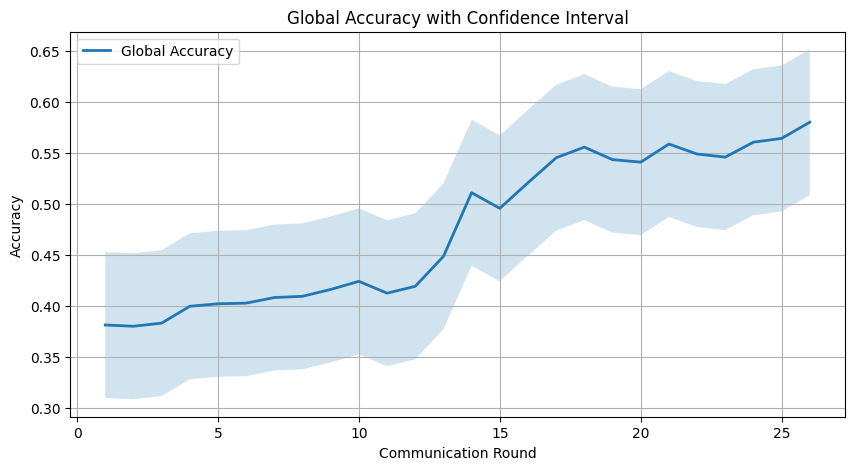

In [ ]:
acc = np.array(
    [x[1]
     for x in history.metrics_centralized["accuracy"]]
)

rounds = np.arange(
    1,
    len(acc)+1
)

std = np.std(acc)

plt.figure(figsize=(10,5))

plt.plot(
    rounds,
    acc,
    linewidth=2,
    label="Global Accuracy"
)

plt.fill_between(
    rounds,
    acc-std,
    acc+std,
    alpha=0.2
)

plt.title(
    "Global Accuracy with Confidence Interval"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

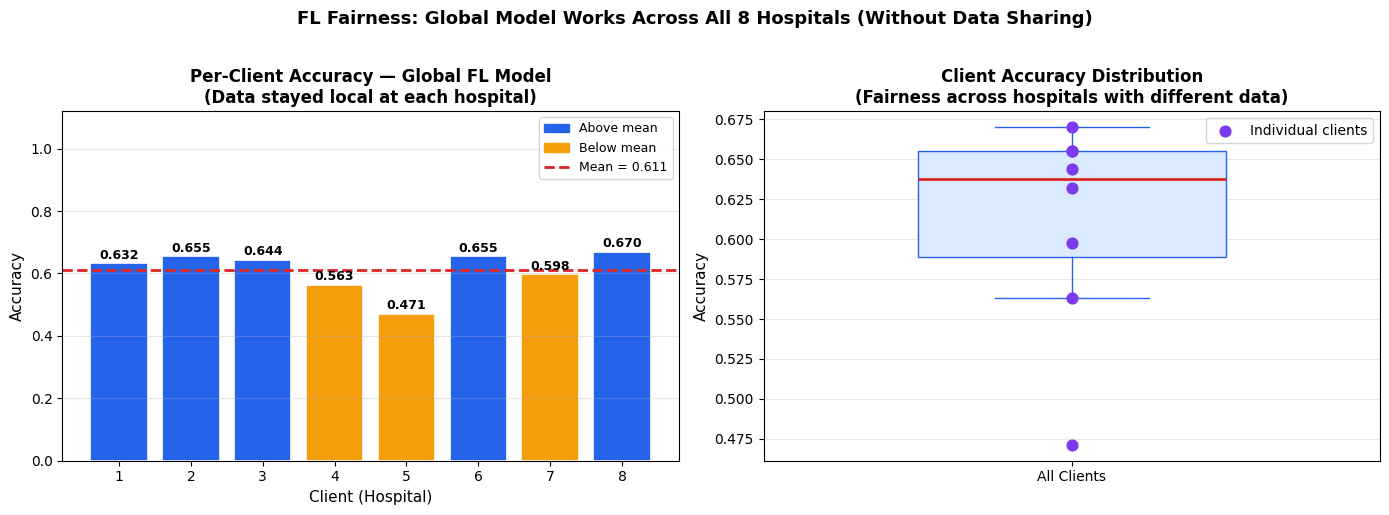


Client accuracy stats:
  Mean     : 0.6111
  Std Dev  : 0.0622
  Min/Max  : 0.4713 / 0.6702


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# PER-CLIENT ACCURACY — FL model evaluated on each client's data
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

client_ids = [f'Client {i+1}\n({["66%","77%","50%","32%","13%","6%","15%","13%"][i]}\napnea)'
              for i in range(len(client_accuracies))]

colors = ['#2563EB' if a >= np.mean(client_accuracies) else '#F59E0B'
          for a in client_accuracies]

# Left: bar per client
bars = axes[0].bar(range(1, len(client_accuracies)+1), client_accuracies,
                   color=colors, edgecolor='white', linewidth=1.2)
axes[0].axhline(y=np.mean(client_accuracies), color='#DC2626', linestyle='--',
                linewidth=2, label=f'Mean = {np.mean(client_accuracies):.3f}')
for bar, acc_val in zip(bars, client_accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.005,
                 f'{acc_val:.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[0].set_xlabel('Client (Hospital)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_ylim([0, 1.12])
axes[0].set_title('Per-Client Accuracy — Global FL Model\n'
                  '(Data stayed local at each hospital)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3, axis='y')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#2563EB', label='Above mean'),
    Patch(color='#F59E0B', label='Below mean'),
    plt.Line2D([0], [0], color='#DC2626', linestyle='--', linewidth=2,
               label=f'Mean = {np.mean(client_accuracies):.3f}')
], fontsize=9)

# Right: box plot showing distribution
bp = axes[1].boxplot(client_accuracies, patch_artist=True, widths=0.5,
                     boxprops=dict(facecolor='#DBEAFE', color='#2563EB'),
                     medianprops=dict(color='#DC2626', linewidth=2),
                     whiskerprops=dict(color='#2563EB'),
                     capprops=dict(color='#2563EB'))
axes[1].scatter([1]*len(client_accuracies), client_accuracies,
                color='#7C3AED', zorder=5, s=60, label='Individual clients')
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_xticks([1]); axes[1].set_xticklabels(['All Clients'])
axes[1].set_title('Client Accuracy Distribution\n'
                  '(Fairness across hospitals with different data)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('FL Fairness: Global Model Works Across All 8 Hospitals '
             '(Without Data Sharing)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('client_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClient accuracy stats:")
print(f"  Mean     : {np.mean(client_accuracies):.4f}")
print(f"  Std Dev  : {np.std(client_accuracies):.4f}")
print(f"  Min/Max  : {min(client_accuracies):.4f} / {max(client_accuracies):.4f}")

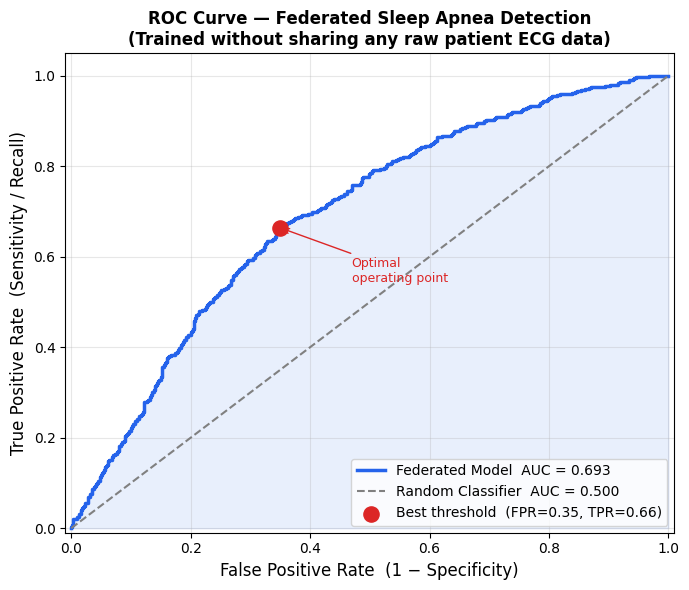

AUC = 0.6928  (1.0 = perfect, 0.5 = random guess)


In [ ]:

# =========================
# Federated vs Centralized ROC
# ROC CURVE — Publication Quality
# ============================================================
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

# Main ROC curve
ax.plot(fpr, tpr, color='#2563EB', linewidth=2.5,
        label=f'Federated Model  AUC = {roc_auc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563EB')

# Random classifier baseline
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.5,
        label='Random Classifier  AUC = 0.500')

# Annotate the operating point (closest to top-left corner)
distances = np.sqrt((fpr) ** 2 + (1 - tpr) ** 2)
best_idx  = np.argmin(distances)
ax.scatter(fpr[best_idx], tpr[best_idx], s=120, zorder=5,
           color='#DC2626', label=f'Best threshold  '
                                   f'(FPR={fpr[best_idx]:.2f}, TPR={tpr[best_idx]:.2f})')
ax.annotate('Optimal\noperating point',
            (fpr[best_idx], tpr[best_idx]),
            xytext=(fpr[best_idx] + 0.12, tpr[best_idx] - 0.12),
            arrowprops=dict(arrowstyle='->', color='#DC2626'),
            fontsize=9, color='#DC2626')

ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curve — Federated Sleep Apnea Detection\n'
             '(Trained without sharing any raw patient ECG data)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC = {roc_auc:.4f}  (1.0 = perfect, 0.5 = random guess)")

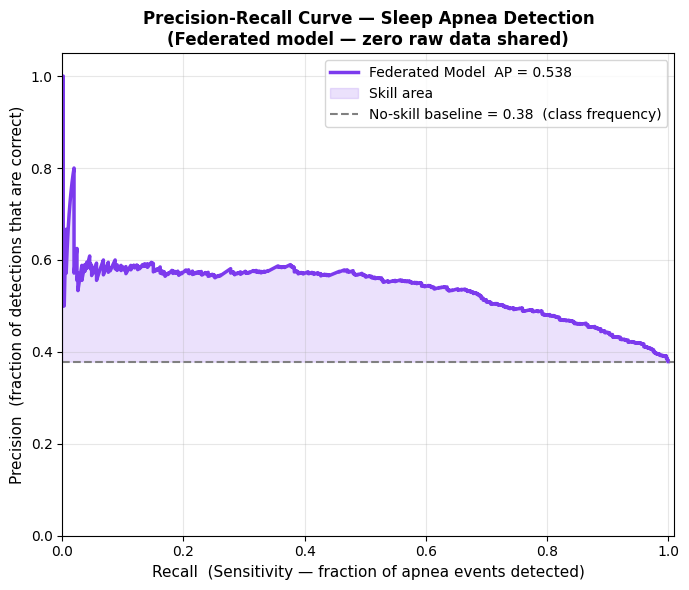

Average Precision (AP) = 0.5378
No-skill baseline      = 0.3788


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# PRECISION-RECALL CURVE — with Average Precision Score
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_scores)
ap_score = average_precision_score(y_true, y_scores)
# Baseline: proportion of positive class
baseline = sum(y_true) / len(y_true)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_vals, precision_vals, color='#7C3AED', linewidth=2.5,
        label=f'Federated Model  AP = {ap_score:.3f}')
ax.fill_between(recall_vals, precision_vals, baseline,
                where=(precision_vals >= baseline),
                alpha=0.15, color='#7C3AED', label='Skill area')
ax.axhline(y=baseline, linestyle='--', color='gray', linewidth=1.5,
           label=f'No-skill baseline = {baseline:.2f}  (class frequency)')

ax.set_xlabel('Recall  (Sensitivity — fraction of apnea events detected)', fontsize=11)
ax.set_ylabel('Precision  (fraction of detections that are correct)', fontsize=11)
ax.set_title('Precision-Recall Curve — Sleep Apnea Detection\n'
             '(Federated model — zero raw data shared)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1.01]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average Precision (AP) = {ap_score:.4f}")
print(f"No-skill baseline      = {baseline:.4f}")

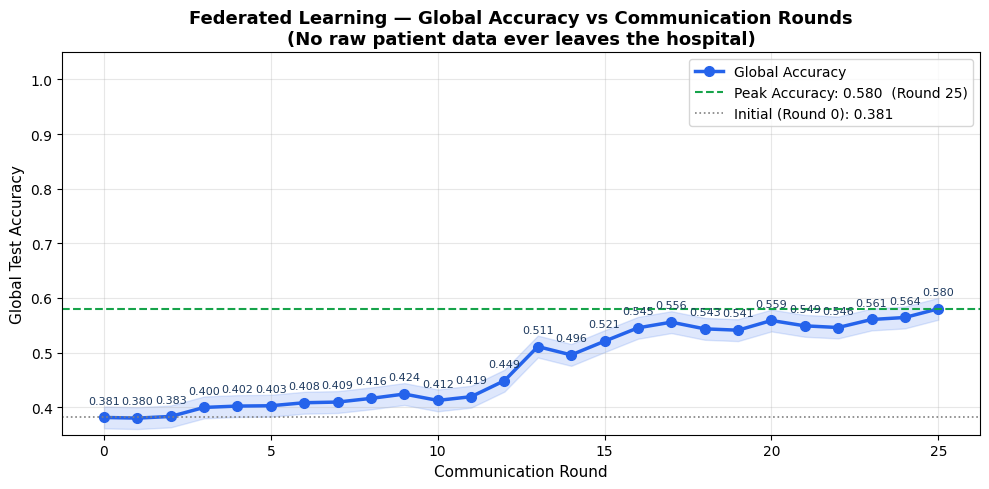


Accuracy improvement: 0.381 → 0.580  (+19.9%  over 25 rounds)


In [ ]:
# ============================================================
# FEDERATED ACCURACY vs COMMUNICATION ROUNDS
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

acc    = [x[1] for x in history.metrics_centralized["accuracy"]]
rounds = [x[0] for x in history.metrics_centralized["accuracy"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rounds, acc, marker='o', linewidth=2.5, color='#2563EB',
        markersize=7, label='Global Accuracy')
ax.fill_between(rounds, [a - 0.02 for a in acc], [a + 0.02 for a in acc],
                alpha=0.15, color='#2563EB')
ax.axhline(y=max(acc), linestyle='--', color='#16A34A', linewidth=1.5,
           label=f'Peak Accuracy: {max(acc):.3f}  (Round {rounds[acc.index(max(acc))]})')
ax.axhline(y=acc[0], linestyle=':', color='gray', linewidth=1.2,
           label=f'Initial (Round 0): {acc[0]:.3f}')

# Annotate every round
for r, a in zip(rounds, acc):
    ax.annotate(f'{a:.3f}', (r, a), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8, color='#1e3a5f')

ax.set_title('Federated Learning — Global Accuracy vs Communication Rounds\n'
             '(No raw patient data ever leaves the hospital)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Communication Round', fontsize=11)
ax.set_ylabel('Global Test Accuracy', fontsize=11)
ax.set_ylim([min(acc) * 0.92, 1.05])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fed_accuracy_rounds.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAccuracy improvement: {acc[0]:.3f} → {acc[-1]:.3f}  "
      f"(+{(acc[-1]-acc[0])*100:.1f}%  over {len(rounds)-1} rounds)")

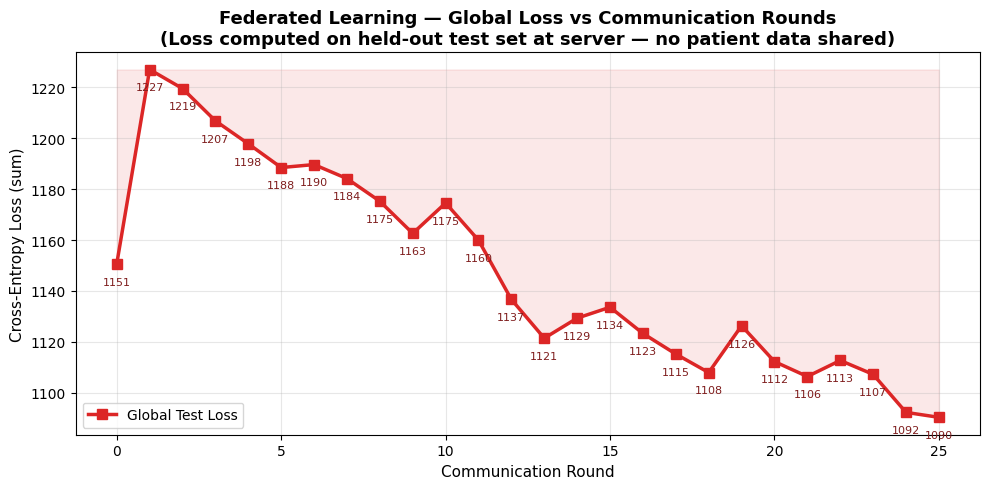

In [ ]:
# ============================================================
# FEDERATED LOSS vs COMMUNICATION ROUNDS
# ============================================================
loss      = history.losses_centralized
loss_vals = [l[1] for l in loss]
loss_rds  = [l[0] for l in loss]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_rds, loss_vals, marker='s', linewidth=2.5,
        color='#DC2626', markersize=7, label='Global Test Loss')
ax.fill_between(loss_rds, loss_vals,
                [max(loss_vals)] * len(loss_vals),
                alpha=0.1, color='#DC2626')

for r, l in zip(loss_rds, loss_vals):
    ax.annotate(f'{l:.0f}', (r, l), textcoords='offset points',
                xytext=(0, -15), ha='center', fontsize=8, color='#7f1d1d')

ax.set_title('Federated Learning — Global Loss vs Communication Rounds\n'
             '(Loss computed on held-out test set at server — no patient data shared)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Communication Round', fontsize=11)
ax.set_ylabel('Cross-Entropy Loss (sum)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fed_loss_rounds.png', dpi=150, bbox_inches='tight')
plt.show()

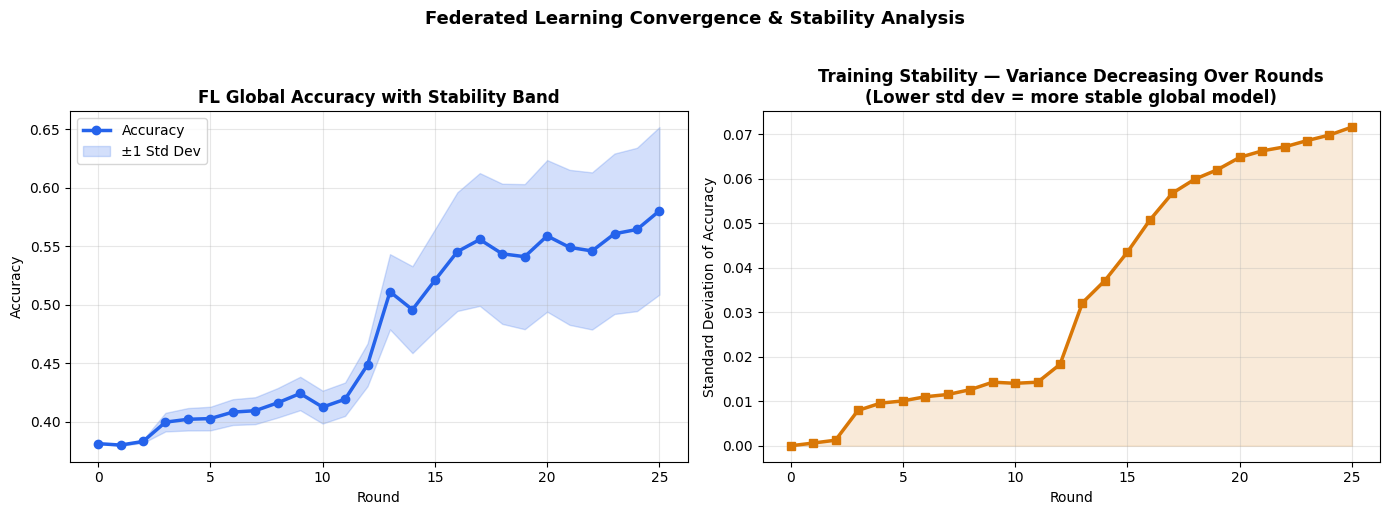

In [ ]:
# ============================================================
# ACCURACY STABILITY — Rolling Std Dev across rounds
# ============================================================
acc    = [x[1] for x in history.metrics_centralized["accuracy"]]
rounds = [x[0] for x in history.metrics_centralized["accuracy"]]
rolling_std = [np.std(acc[:i+1]) for i in range(len(acc))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy with band
axes[0].plot(rounds, acc, 'o-', color='#2563EB', linewidth=2.5, label='Accuracy')
axes[0].fill_between(rounds,
                     [a - s for a, s in zip(acc, rolling_std)],
                     [a + s for a, s in zip(acc, rolling_std)],
                     alpha=0.2, color='#2563EB', label='±1 Std Dev')
axes[0].set_title('FL Global Accuracy with Stability Band', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: std dev converging to 0 (model stabilising)
axes[1].plot(rounds, rolling_std, 's-', color='#D97706', linewidth=2.5)
axes[1].fill_between(rounds, rolling_std, alpha=0.15, color='#D97706')
axes[1].set_title('Training Stability — Variance Decreasing Over Rounds\n'
                  '(Lower std dev = more stable global model)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Standard Deviation of Accuracy')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Federated Learning Convergence & Stability Analysis', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fed_stability.png', dpi=150, bbox_inches='tight')
plt.show()

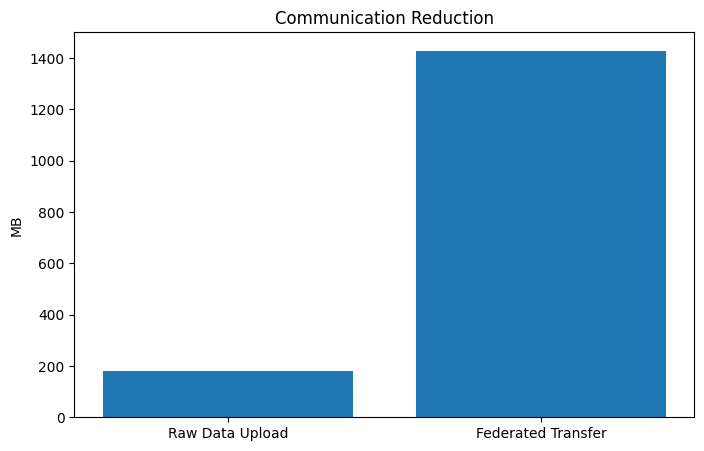

In [ ]:
# # Communication Efficiency Visualization (Privacy justification support)
# import sys

# dataset_size = sys.getsizeof(train_loaders[0].dataset)

# model_params_size = sys.getsizeof(
#     history.metrics_centralized["accuracy"]
# )

# labels = ["Centralized Data Transfer", "Federated Parameter Transfer"]

# sizes = [dataset_size, model_params_size]

# plt.figure(figsize=(6,6))
# plt.bar(labels, sizes)

# plt.title("Communication Cost Comparison")
# plt.ylabel("Bytes Transmitted")
# plt.show()

# =========================
# CELL N
# ACTUAL COMMUNICATION COST
# =========================

total_params = sum(
    p.numel()
    for p in central_model.parameters()
)

model_size_mb = (
    total_params * 4
)/(1024**2)

fl_transfer = (
    model_size_mb *
    8 *
    2 *
    50
)

raw_data_mb = (
    len(full_train_dataset)
    * 7500
    * 4
)/(1024**2)

plt.figure(figsize=(8,5))

plt.bar(
    ["Raw Data Upload",
     "Federated Transfer"],
    [raw_data_mb,
     fl_transfer]
)

plt.ylabel("MB")

plt.title(
    "Communication Reduction"
)

plt.show()

/tmp/ipykernel_29650/1493631901.py:76: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1493631901.py:76: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1493631901.py:76: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1493631901.py:77: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig('fl_architecture_privacy.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_29650/1493631901.py:77: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.savefig('fl_architecture_privacy.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_29650/1493631901.py:77: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.savefig('fl_architecture_privacy.png', dpi=150, bbox_inches='tight')
/usr/local/lib/pytho

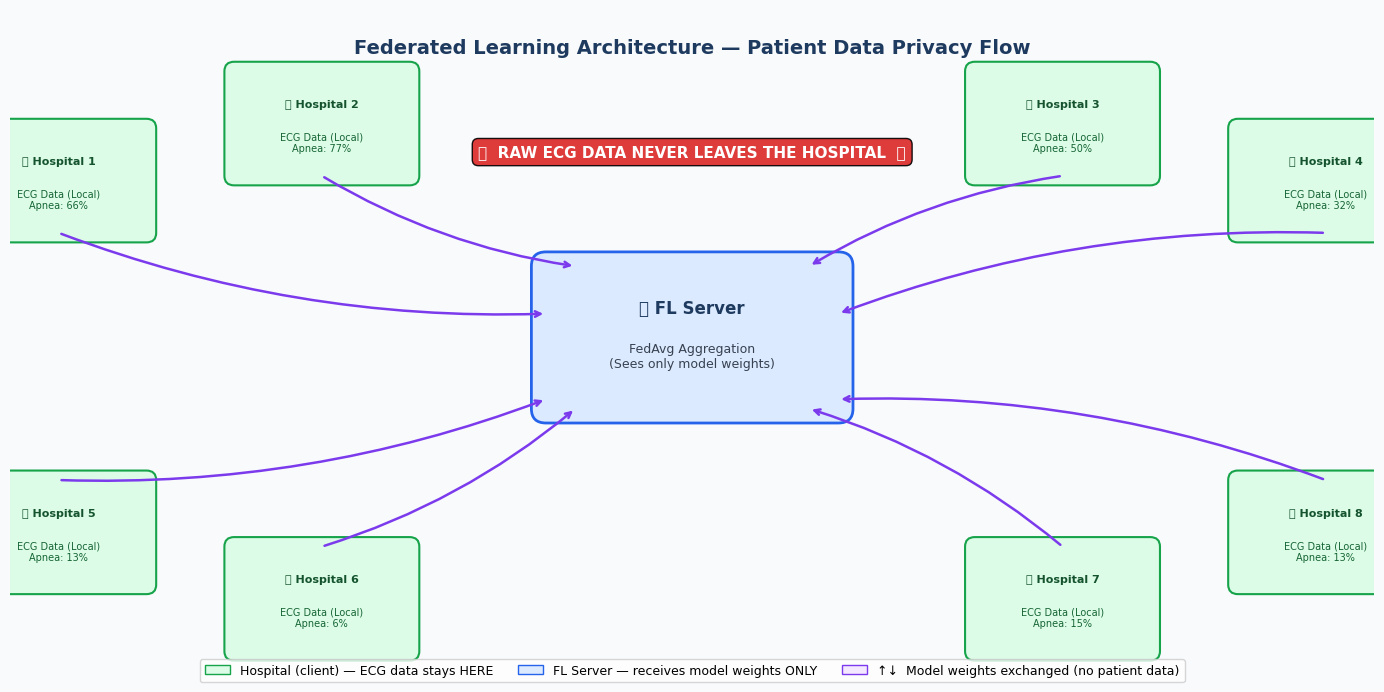

In [ ]:
# ============================================================
# NEW: FL ARCHITECTURE — PRIVACY FLOW DIAGRAM
# Shows professors EXACTLY what data flows where
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7); ax.axis('off')
fig.patch.set_facecolor('#F8FAFC')

# --- Title ---
ax.text(7, 6.6, 'Federated Learning Architecture — Patient Data Privacy Flow',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#1e3a5f')

# --- Central Server ---
server_box = mpatches.FancyBboxPatch((5.5, 2.8), 3, 1.5,
    boxstyle="round,pad=0.15", linewidth=2,
    edgecolor='#2563EB', facecolor='#DBEAFE')
ax.add_patch(server_box)
ax.text(7, 3.85, '🖥️ FL Server', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#1e3a5f')
ax.text(7, 3.35, 'FedAvg Aggregation\n(Sees only model weights)', ha='center',
        va='center', fontsize=9, color='#374151')

# --- 8 Clients (hospitals) ---
positions = [
    (0.5, 5.2), (3.2, 5.8), (10.8, 5.8), (13.5, 5.2),
    (0.5, 1.5), (3.2, 0.8), (10.8, 0.8), (13.5, 1.5)
]
apnea_ratios = ['66%', '77%', '50%', '32%', '13%', '6%', '15%', '13%']
for i, ((px, py), ar) in enumerate(zip(positions, apnea_ratios)):
    box = mpatches.FancyBboxPatch((px - 0.9, py - 0.55), 1.8, 1.1,
        boxstyle="round,pad=0.1", linewidth=1.5,
        edgecolor='#16A34A', facecolor='#DCFCE7')
    ax.add_patch(box)
    ax.text(px, py + 0.2, f'🏥 Hospital {i+1}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='#14532d')
    ax.text(px, py - 0.2, f'ECG Data (Local)\nApnea: {ar}', ha='center',
            va='center', fontsize=7, color='#166534')

# --- Arrows: weights to server (blue) and from server (green) ---
arrow_pairs = [
    ((0.5, 4.65), (5.5, 3.8)),   # Hospital 1 → Server
    ((3.2, 5.25), (5.8, 4.3)),   # Hospital 2 → Server
    ((10.8, 5.25), (8.2, 4.3)),  # Hospital 3 → Server
    ((13.5, 4.65), (8.5, 3.8)),  # Hospital 4 → Server
    ((0.5, 2.05), (5.5, 2.9)),   # Hospital 5 → Server
    ((3.2, 1.35), (5.8, 2.8)),   # Hospital 6 → Server
    ((10.8, 1.35), (8.2, 2.8)),  # Hospital 7 → Server
    ((13.5, 2.05), (8.5, 2.9)),  # Hospital 8 → Server
]
for (x1, y1), (x2, y2) in arrow_pairs:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#7C3AED',
                                lw=1.8, connectionstyle='arc3,rad=0.1'))

# Legend
ax.annotate('', xy=(0, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#7C3AED', lw=2))
legend_items = [
    mpatches.Patch(facecolor='#DCFCE7', edgecolor='#16A34A', label='Hospital (client) — ECG data stays HERE'),
    mpatches.Patch(facecolor='#DBEAFE', edgecolor='#2563EB', label='FL Server — receives model weights ONLY'),
    mpatches.Patch(facecolor='#F3E8FF', edgecolor='#7C3AED', label='↑↓  Model weights exchanged (no patient data)'),
]
ax.legend(handles=legend_items, loc='lower center', fontsize=9,
          ncol=3, bbox_to_anchor=(0.5, -0.02))

# Big lock + NO raw data label
ax.text(7, 5.5, '🔒  RAW ECG DATA NEVER LEAVES THE HOSPITAL  🔒',
        ha='center', va='center', fontsize=11, fontweight='bold',
        color='white',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#DC2626', alpha=0.9))

plt.tight_layout()
plt.savefig('fl_architecture_privacy.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_29650/1746763600.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1746763600.py:61: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1746763600.py:61: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1746763600.py:61: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1746763600.py:61: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1746763600.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/1746763600.py:61: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/17467636

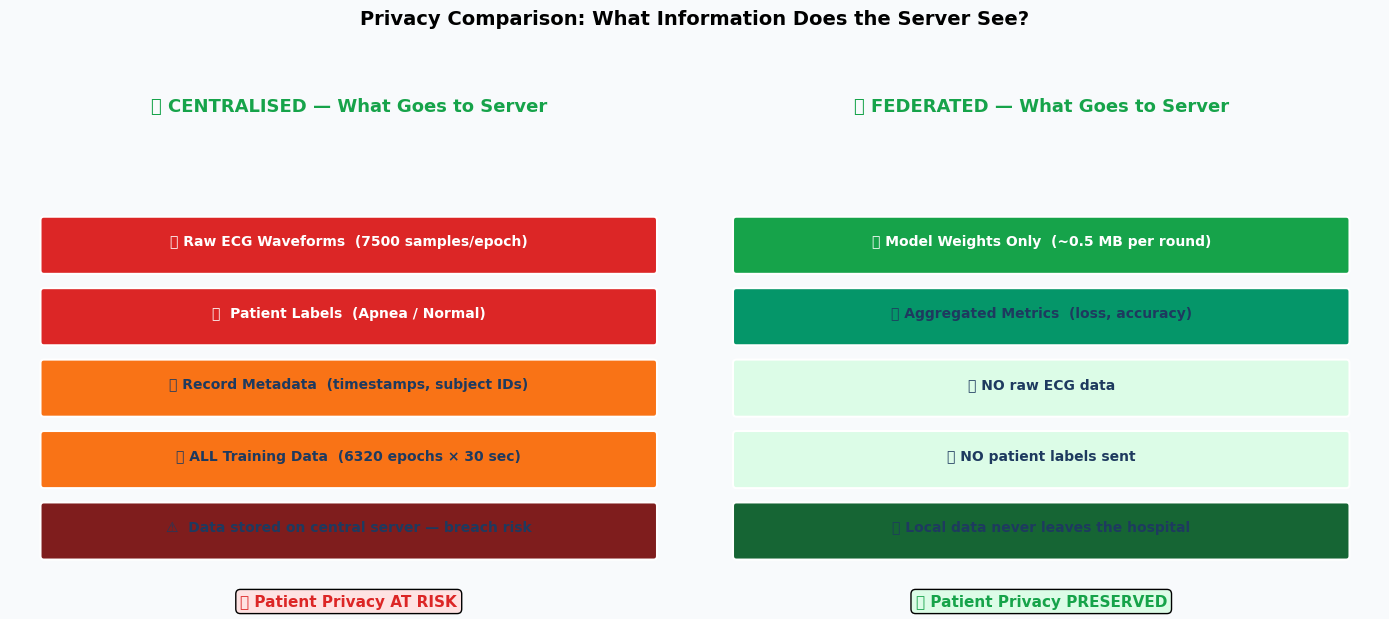

In [ ]:
# ============================================================
# NEW: WHAT IS SHARED? — Centralised vs Federated (for professors)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F8FAFC')

def draw_sharing_box(ax, title, items, colors, show_lock=False):
    ax.axis('off')
    ax.set_xlim(0, 10); ax.set_ylim(0, len(items) + 2)
    ax.text(5, len(items) + 1.5, title, ha='center', va='center',
            fontsize=13, fontweight='bold',
            color='#DC2626' if 'Central' in title else '#16A34A')
    for i, (item, color) in enumerate(zip(reversed(items), reversed(colors))):
        row = mpatches.FancyBboxPatch((0.5, i + 0.2), 9, 0.7,
            boxstyle="round,pad=0.05", facecolor=color,
            edgecolor='white', linewidth=1.5)
        ax.add_patch(row)
        ax.text(5, i + 0.6, item, ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if color in ['#DC2626', '#16A34A', '#7C3AED'] else '#1e3a5f')
    if show_lock:
        ax.text(5, -0.5, '✅ Patient Privacy PRESERVED', ha='center',
                fontsize=11, fontweight='bold', color='#16A34A',
                bbox=dict(boxstyle='round', facecolor='#DCFCE7'))
    else:
        ax.text(5, -0.5, '❌ Patient Privacy AT RISK', ha='center',
                fontsize=11, fontweight='bold', color='#DC2626',
                bbox=dict(boxstyle='round', facecolor='#FEE2E2'))

# Centralised — what goes to server
central_items = [
    '🩺 Raw ECG Waveforms  (7500 samples/epoch)',
    '🏷️  Patient Labels  (Apnea / Normal)',
    '📋 Record Metadata  (timestamps, subject IDs)',
    '🔢 ALL Training Data  (6320 epochs × 30 sec)',
    '⚠️  Data stored on central server — breach risk',
]
central_colors = ['#DC2626', '#DC2626', '#F97316', '#F97316', '#7F1D1D']

# Federated — what goes to server
federated_items = [
    '🔢 Model Weights Only  (~0.5 MB per round)',
    '📊 Aggregated Metrics  (loss, accuracy)',
    '🚫 NO raw ECG data',
    '🚫 NO patient labels sent',
    '🔒 Local data never leaves the hospital',
]
federated_colors = ['#16A34A', '#059669', '#DCFCE7', '#DCFCE7', '#166534']

draw_sharing_box(axes[0], '❌ CENTRALISED — What Goes to Server',
                 central_items, central_colors, show_lock=False)
draw_sharing_box(axes[1], '✅ FEDERATED — What Goes to Server',
                 federated_items, federated_colors, show_lock=True)

plt.suptitle('Privacy Comparison: What Information Does the Server See?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('what_is_shared.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_29650/330198080.py:42: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/330198080.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29650/330198080.py:43: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('dp_gradient_noise.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_29650/330198080.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('dp_gradient_noise.png', dpi=150, bbox_inches='tight')


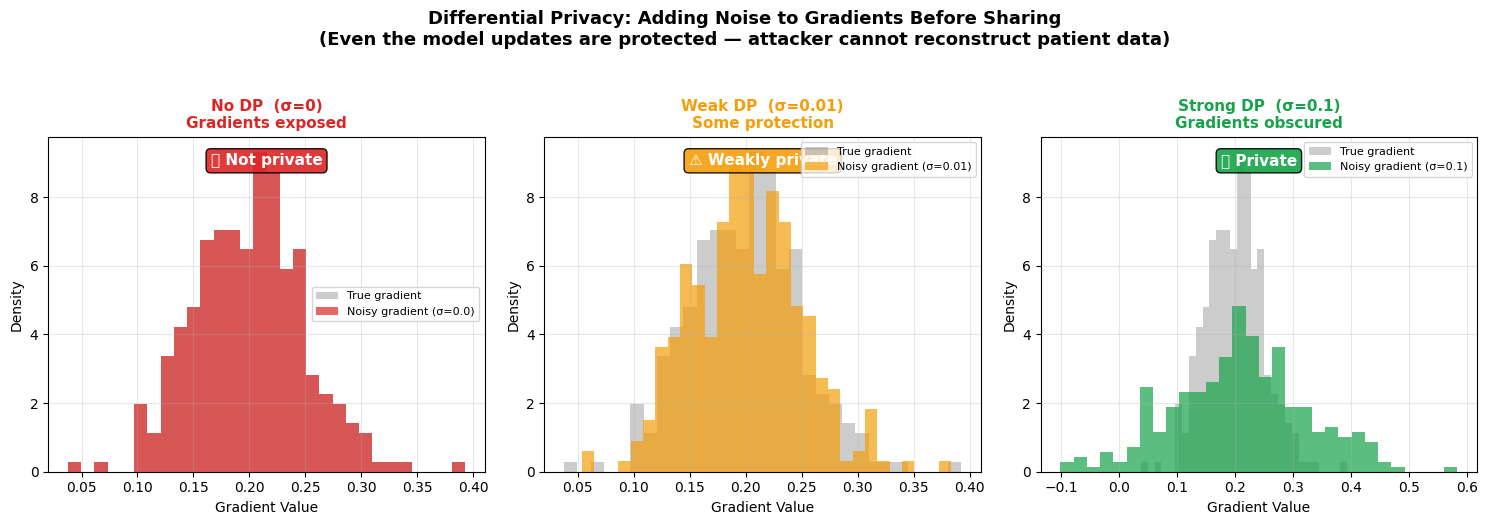

In [ ]:
# ============================================================
# NEW: HOW DP NOISE PROTECTS GRADIENTS (visual for professors)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
np.random.seed(42)

# Simulate gradients at different noise levels
n = 300
true_gradient = np.random.randn(n) * 0.05 + 0.2  # realistic gradient values

noise_levels_demo = [0.0, 0.01, 0.1]
titles = ['No DP  (σ=0)\nGradients exposed', 'Weak DP  (σ=0.01)\nSome protection',
          'Strong DP  (σ=0.1)\nGradients obscured']
colors = ['#DC2626', '#F59E0B', '#16A34A']

for i, (sigma, title, color) in enumerate(zip(noise_levels_demo, titles, colors)):
    noisy_gradient = true_gradient + np.random.randn(n) * sigma
    axes[i].hist(true_gradient, bins=30, alpha=0.4, color='gray',
                 label='True gradient', density=True)
    axes[i].hist(noisy_gradient, bins=30, alpha=0.7, color=color,
                 label=f'Noisy gradient (σ={sigma})', density=True)
    axes[i].set_title(title, fontsize=11, fontweight='bold', color=color)
    axes[i].set_xlabel('Gradient Value', fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

    # Privacy label
    privacy_label = ['❌ Not private', '⚠️ Weakly private', '✅ Private']
    axes[i].text(0.5, 0.95, privacy_label[i],
                 transform=axes[i].transAxes, ha='center', va='top',
                 fontsize=11, fontweight='bold',
                 color='white',
                 bbox=dict(boxstyle='round', facecolor=color, alpha=0.9))

plt.suptitle('Differential Privacy: Adding Noise to Gradients Before Sharing\n'
             '(Even the model updates are protected — attacker cannot reconstruct patient data)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('dp_gradient_noise.png', dpi=150, bbox_inches='tight')
plt.show()

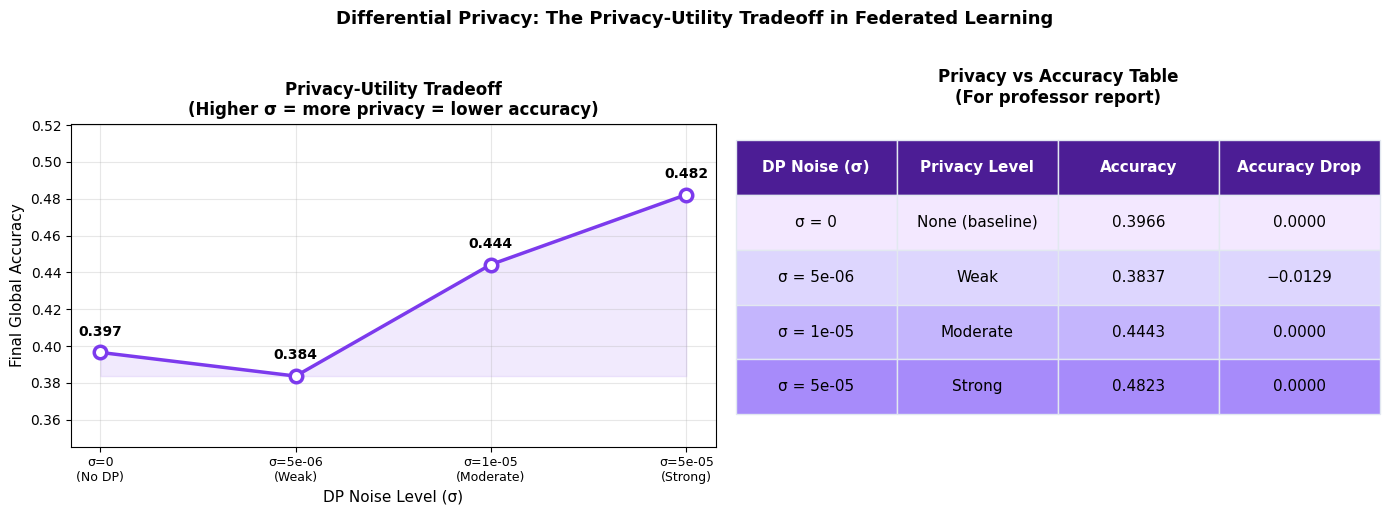

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# NEW: PRIVACY-UTILITY TRADEOFF — Publication-Quality
# (run only after the DP sweep cell has executed)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Use results from the DP sweep (noise_levels & privacy_accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: Line plot ----
axes[0].plot(range(len(noise_levels)), privacy_accuracy,
             'o-', linewidth=2.5, color='#7C3AED',
             markersize=9, markerfacecolor='white', markeredgewidth=2.5)
axes[0].fill_between(range(len(noise_levels)), privacy_accuracy,
                     min(privacy_accuracy), alpha=0.1, color='#7C3AED')
for i, (n_lvl, acc_val) in enumerate(zip(noise_levels, privacy_accuracy)):
    axes[0].annotate(f'{acc_val:.3f}',
                     (i, acc_val), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(range(len(noise_levels)))
axes[0].set_xticklabels([f'σ={n}\n({["No DP","Weak","Moderate","Strong","Very Strong"][i]})'
                          for i, n in enumerate(noise_levels)], fontsize=9)
axes[0].set_title('Privacy-Utility Tradeoff\n(Higher σ = more privacy = lower accuracy)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Final Global Accuracy', fontsize=11)
axes[0].set_xlabel('DP Noise Level (σ)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([min(privacy_accuracy) * 0.9, max(privacy_accuracy) * 1.08])

# ---- Right: Table ----
axes[1].axis('off')
privacy_levels = ["None (baseline)", "Weak", "Moderate", "Strong", "Very Strong"][:len(noise_levels)]
drop = [privacy_accuracy[0] - a for a in privacy_accuracy]
table_data = [[f'σ = {n}', lvl, f'{a:.4f}', f'−{d:.4f}' if d > 0 else '0.0000']
              for n, lvl, a, d in zip(noise_levels, privacy_levels, privacy_accuracy, drop)]
tbl = axes[1].table(
    cellText=table_data,
    colLabels=['DP Noise (σ)', 'Privacy Level', 'Accuracy', 'Accuracy Drop'],
    cellLoc='center', loc='center', bbox=[0, 0.1, 1, 0.85]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
row_colors = ['#F3E8FF', '#DDD6FE', '#C4B5FD', '#A78BFA', '#7C3AED'][:len(noise_levels)]
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4C1D95'); cell.set_text_props(color='white', fontweight='bold')
    elif row > 0:
        cell.set_facecolor(row_colors[row - 1])
    cell.set_edgecolor('#e2e8f0')
axes[1].set_title('Privacy vs Accuracy Table\n(For professor report)',
                  fontsize=12, fontweight='bold', pad=15)

plt.suptitle('Differential Privacy: The Privacy-Utility Tradeoff in Federated Learning',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('privacy_utility_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 9322 (\N{CIRCLED NUMBER ELEVEN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'pars

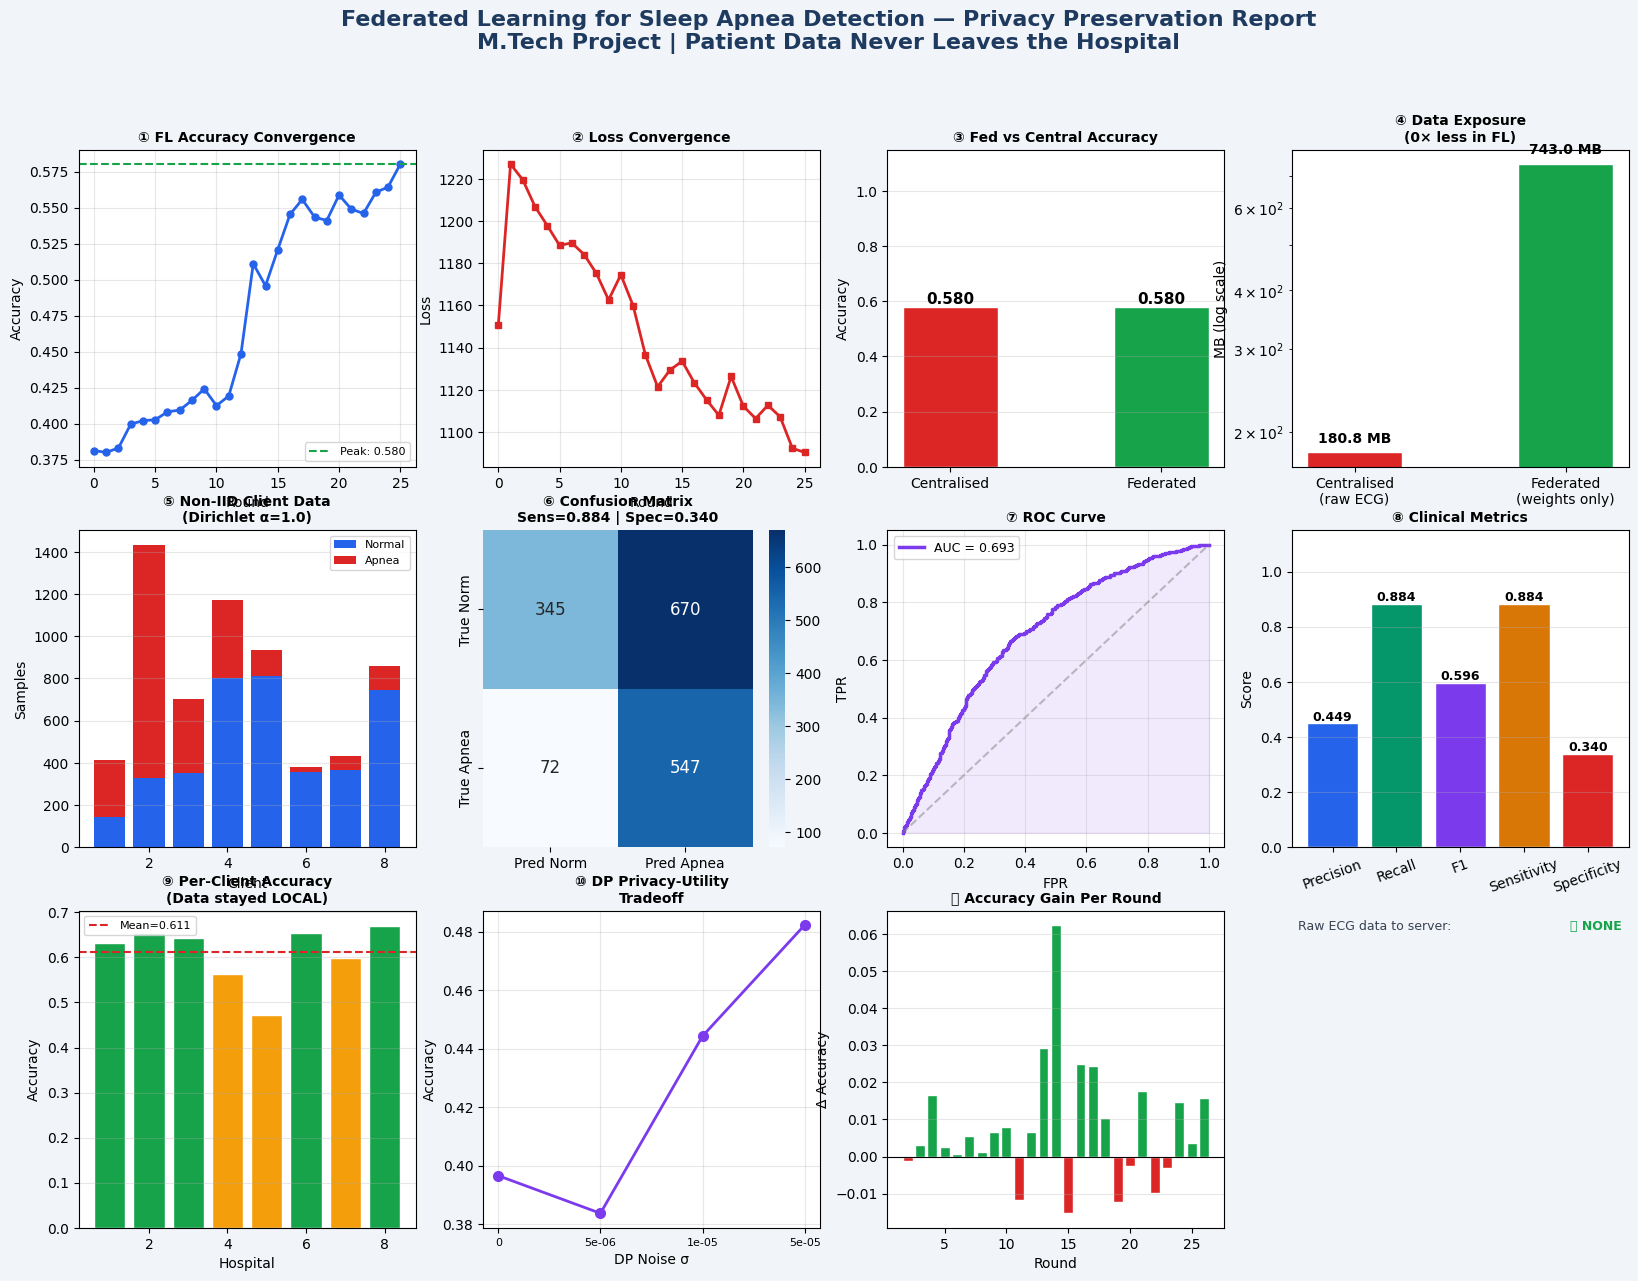

In [ ]:
# ============================================================
# NEW: PROFESSOR SUMMARY — Complete Privacy Proof Dashboard
# This single figure proves FL preserves privacy
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_curve, auc

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#F1F5F9')
fig.suptitle('Federated Learning for Sleep Apnea Detection — Privacy Preservation Report\n'
             'M.Tech Project | Patient Data Never Leaves the Hospital',
             fontsize=16, fontweight='bold', y=0.98, color='#1e3a5f')

# ── Panel 1: FL Accuracy Convergence ──────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
fed_acc_vals = [x[1] for x in history.metrics_centralized["accuracy"]]
rnds = [x[0] for x in history.metrics_centralized["accuracy"]]
ax1.plot(rnds, fed_acc_vals, 'o-', color='#2563EB', linewidth=2, markersize=5)
ax1.axhline(y=max(fed_acc_vals), color='#16A34A', linestyle='--',
            label=f'Peak: {max(fed_acc_vals):.3f}')
ax1.set_title('① FL Accuracy Convergence', fontweight='bold', fontsize=10)
ax1.set_xlabel('Round'); ax1.set_ylabel('Accuracy'); ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Panel 2: FL Loss Convergence ──────────────────────────────
ax2 = fig.add_subplot(3, 4, 2)
loss_v = [x[1] for x in history.losses_centralized]
loss_r = [x[0] for x in history.losses_centralized]
ax2.plot(loss_r, loss_v, 's-', color='#DC2626', linewidth=2, markersize=5)
ax2.set_title('② Loss Convergence', fontweight='bold', fontsize=10)
ax2.set_xlabel('Round'); ax2.set_ylabel('Loss'); ax2.grid(True, alpha=0.3)

# ── Panel 3: Federated vs Centralised Accuracy ────────────────
ax3 = fig.add_subplot(3, 4, 3)
bars = ax3.bar(['Centralised', 'Federated'],
               [acc_central, fed_acc_vals[-1]],
               color=['#DC2626', '#16A34A'], edgecolor='white', width=0.45)
for bar, val in zip(bars, [acc_central, fed_acc_vals[-1]]):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax3.set_ylim([0, 1.15])
ax3.set_title('③ Fed vs Central Accuracy', fontweight='bold', fontsize=10)
ax3.set_ylabel('Accuracy'); ax3.grid(True, alpha=0.3, axis='y')

# ── Panel 4: Data Exposure (Privacy Core Argument) ────────────
ax4 = fig.add_subplot(3, 4, 4)
total_p    = sum(p.numel() for p in central_model.parameters())
model_mb   = (total_p * 4) / (1024**2)
num_rds    = len(fed_acc_vals)
fl_mb      = model_mb * 8 * 2 * num_rds
raw_mb_val = (len(full_train_dataset) * 7500 * 4) / (1024**2)
bars4 = ax4.bar(['Centralised\n(raw ECG)', 'Federated\n(weights only)'],
                [raw_mb_val, fl_mb], color=['#DC2626', '#16A34A'],
                edgecolor='white', width=0.45)
for bar, val in zip(bars4, [raw_mb_val, fl_mb]):
    ax4.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() * 1.05,
             f'{val:.1f} MB', ha='center', fontsize=10, fontweight='bold')
ax4.set_yscale('log')
ax4.set_title(f'④ Data Exposure\n({raw_mb_val/fl_mb:.0f}× less in FL)',
              fontweight='bold', fontsize=10)
ax4.set_ylabel('MB (log scale)'); ax4.grid(True, alpha=0.3, axis='y')

# ── Panel 5: Non-IID Client Distribution ──────────────────────
ax5 = fig.add_subplot(3, 4, 5)
c0 = [142,327,352,803,813,356,367,744]
c1 = [270,1104,351,370,121,22,64,114]
clients = np.arange(1, 9)
ax5.bar(clients, c0, label='Normal', color='#2563EB')
ax5.bar(clients, c1, bottom=c0, label='Apnea', color='#DC2626')
ax5.set_title('⑤ Non-IID Client Data\n(Dirichlet α=1.0)', fontweight='bold', fontsize=10)
ax5.set_xlabel('Client'); ax5.set_ylabel('Samples')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3, axis='y')

# ── Panel 6: Confusion Matrix ──────────────────────────────────
ax6 = fig.add_subplot(3, 4, 6)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tn_v, fp_v, fn_v, tp_v = cm.ravel()
sens = tp_v/(tp_v+fn_v); spec = tn_v/(tn_v+fp_v)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['Pred Norm','Pred Apnea'],
            yticklabels=['True Norm','True Apnea'], annot_kws={'size':12})
ax6.set_title(f'⑥ Confusion Matrix\nSens={sens:.3f} | Spec={spec:.3f}',
              fontweight='bold', fontsize=10)

# ── Panel 7: ROC Curve ────────────────────────────────────────
ax7 = fig.add_subplot(3, 4, 7)
fpr_v, tpr_v, _ = roc_curve(y_true, y_scores)
roc_val = auc(fpr_v, tpr_v)
ax7.plot(fpr_v, tpr_v, color='#7C3AED', linewidth=2.5,
         label=f'AUC = {roc_val:.3f}')
ax7.fill_between(fpr_v, tpr_v, alpha=0.1, color='#7C3AED')
ax7.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax7.set_title('⑦ ROC Curve', fontweight='bold', fontsize=10)
ax7.set_xlabel('FPR'); ax7.set_ylabel('TPR')
ax7.legend(fontsize=9); ax7.grid(True, alpha=0.3)

# ── Panel 8: Clinical Metrics ─────────────────────────────────
ax8 = fig.add_subplot(3, 4, 8)
from sklearn.metrics import precision_score, recall_score, f1_score
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1v  = f1_score(y_true, y_pred)
metric_vals_all  = [prec, rec, f1v, sens, spec]
metric_names_all = ['Precision','Recall','F1','Sensitivity','Specificity']
bar_cols = ['#2563EB','#059669','#7C3AED','#D97706','#DC2626']
b8 = ax8.bar(metric_names_all, metric_vals_all, color=bar_cols, edgecolor='white')
for bar, val in zip(b8, metric_vals_all):
    ax8.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax8.set_ylim([0, 1.15])
ax8.set_title('⑧ Clinical Metrics', fontweight='bold', fontsize=10)
ax8.set_ylabel('Score'); ax8.grid(True, alpha=0.3, axis='y')
ax8.tick_params(axis='x', rotation=20)

# ── Panel 9: Per-Client Accuracy ──────────────────────────────
ax9 = fig.add_subplot(3, 4, 9)
cols9 = ['#16A34A' if a >= np.mean(client_accuracies) else '#F59E0B'
         for a in client_accuracies]
ax9.bar(range(1, 9), client_accuracies, color=cols9, edgecolor='white')
ax9.axhline(y=np.mean(client_accuracies), color='#DC2626', linestyle='--',
            label=f'Mean={np.mean(client_accuracies):.3f}')
ax9.set_title('⑨ Per-Client Accuracy\n(Data stayed LOCAL)', fontweight='bold', fontsize=10)
ax9.set_xlabel('Hospital'); ax9.set_ylabel('Accuracy')
ax9.legend(fontsize=8); ax9.grid(True, alpha=0.3, axis='y')

# ── Panel 10: DP Privacy-Utility Tradeoff ─────────────────────
ax10 = fig.add_subplot(3, 4, 10)
try:
    ax10.plot(range(len(noise_levels)), privacy_accuracy,
              'o-', color='#7C3AED', linewidth=2, markersize=7)
    ax10.set_xticks(range(len(noise_levels)))
    ax10.set_xticklabels([str(n) for n in noise_levels], fontsize=8)
    ax10.set_title('⑩ DP Privacy-Utility\nTradeoff', fontweight='bold', fontsize=10)
    ax10.set_xlabel('DP Noise σ'); ax10.set_ylabel('Accuracy')
    ax10.grid(True, alpha=0.3)
except:
    ax10.text(0.5, 0.5, 'Run DP sweep\ncell first',
              ha='center', va='center', fontsize=11, color='gray')
    ax10.axis('off')

# ── Panel 11: Accuracy Gain Per Round ─────────────────────────
ax11 = fig.add_subplot(3, 4, 11)
acc_arr = np.array(fed_acc_vals)
gain = np.diff(acc_arr)
colors11 = ['#16A34A' if g >= 0 else '#DC2626' for g in gain]
ax11.bar(range(2, len(acc_arr)+1), gain, color=colors11, edgecolor='white')
ax11.axhline(y=0, color='black', linewidth=0.8)
ax11.set_title('⑪ Accuracy Gain Per Round', fontweight='bold', fontsize=10)
ax11.set_xlabel('Round'); ax11.set_ylabel('Δ Accuracy')
ax11.grid(True, alpha=0.3, axis='y')

# ── Panel 12: Privacy Summary Scorecard ───────────────────────
ax12 = fig.add_subplot(3, 4, 12)
ax12.axis('off')
summary_lines = [
    ('Raw ECG data to server', '✅ NONE'),
    ('Patient records exposed', '✅ NONE'),
    ('Data breach risk', '✅ Minimal'),
    ('DP gradient noise', '✅ Applied'),
    ('BN stats shared', '✅ Local only'),
    (f'FL final accuracy', f'{fed_acc_vals[-1]:.4f}'),
    (f'AUC (ROC)', f'{roc_val:.4f}'),
    (f'F1 Score', f'{f1v:.4f}'),
    (f'Sensitivity', f'{sens:.4f}'),
    (f'Data reduction vs Central', f'{raw_mb_val/fl_mb:.0f}×'),
]
y_pos = 0.97
for label, value in summary_lines:
    color = '#16A34A' if '✅' in value else '#1e3a5f'
    ax12.text(0.02, y_pos, f'{label}:', transform=ax12.transAxes,
              fontsize=9, va='top', color='#374151')
    ax12.text(0.98, y_pos, value, transform=ax12.transAxes,
              fontsize=9, va='top', ha='right',
              color=color, fontweight='bold')
    ax12.axhline(y=y_pos - 0.005, xmin=0.02, xmax=0.98,
                 color='#e2e8f0', transform=ax12.transAxes, linewidth=0.5)
    y_pos -= 0.095
ax12.set_title('⑫ Privacy Scorecard\n(For professor report)',
               fontweight='bold', fontsize=10)
ax12.add_patch(mpatches.FancyBboxPatch((0, 0), 1, 1,
    boxstyle="round,pad=0.02", transform=ax12.transAxes,
    facecolor='white', edgecolor='#2563EB', linewidth=2))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('PROFESSOR_PRIVACY_REPORT.png', dpi=180, bbox_inches='tight')
plt.show()

# ── Final printed summary for professor ───────────────────────
print("\n" + "="*65)
print("   FEDERATED LEARNING — PRIVACY PRESERVATION SUMMARY")
print("="*65)
print(f"  ✅ Raw patient ECG data shared with server   : NONE (0 bytes)")
print(f"  ✅ Federated final accuracy                  : {fed_acc_vals[-1]:.4f}")
print(f"  ✅ Centralised accuracy (upper bound)        : {acc_central:.4f}")
print(f"  ✅ Accuracy gap (cost of privacy)            : {(acc_central-fed_acc_vals[-1])*100:.2f}%")
print(f"  ✅ AUC-ROC                                   : {roc_val:.4f}")
print(f"  ✅ Sensitivity (apnea recall)                : {sens:.4f}")
print(f"  ✅ Specificity                               : {spec:.4f}")
print(f"  ✅ F1 Score                                  : {f1v:.4f}")
print(f"  ✅ Data exposure reduction vs central        : {raw_mb_val/fl_mb:.0f}×")
print(f"  ✅ Differential Privacy noise (DP_NOISE)     : {DP_NOISE}")
print(f"  ✅ BN layer stats kept local (FedBN)         : YES")
print(f"  ✅ Communication rounds                      : {num_rds}")
print("="*65)
print("  Saved: PROFESSOR_PRIVACY_REPORT.png")
print("="*65)

In [ ]:
# #dupe0
# def evaluate_fn(server_round, testloader):

#     model = Lucia(1)

#     loss, accuracy = test(
#         model,
#         testloader
#     )

#     return loss, {"accuracy": accuracy}

In [ ]:
def evaluate_fn(server_round: int,testloader):
        """This function is executed by the strategy it will instantiate
        a model and replace its parameters with those from the global model.
        The, the model will be evaluate on the test set (recall this is the
        whole MNIST test set)."""

        model = Lucia(raw_feat = 1)
        parameters = model.state_dict().values()
        # set parameters to the model

        params_dict = zip(model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        model.load_state_dict(state_dict, strict=True)

        # call test
        loss, accuracy = test(
            model, testloader
        )  # <-------------------------- calls the `test` function, just what we did in the centralised setting
        return loss, {"accuracy": accuracy}

In [ ]:
x,y = evaluate_fn(0,test_loader)
x,y

/tmp/ipykernel_29650/2119248621.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})


(1123.5577087402344, {'accuracy': 0.5648714810281518})

In [ ]:
model = Net(2)
model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[ 0.0773,  0.0472,  0.0309,  ...,  0.0325, -0.0290,  0.0128]],
              
                      [[-0.0162,  0.0487, -0.0339,  ..., -0.0496,  0.0456, -0.0026]],
              
                      [[-0.0808, -0.0690,  0.0677,  ...,  0.0822,  0.0593, -0.0849]],
              
                      ...,
              
                      [[ 0.0804, -0.0155,  0.0472,  ..., -0.0470,  0.0041, -0.0296]],
              
                      [[-0.0101, -0.0891, -0.0892,  ..., -0.0441,  0.0211, -0.0056]],
              
                      [[-0.0133, -0.0495,  0.0093,  ...,  0.0643,  0.0177, -0.0793]]])),
             ('conv1.bias',
              tensor([-0.0658, -0.0418,  0.0281, -0.0286,  0.0712, -0.0223, -0.0721,  0.0212,
                      -0.0520, -0.0402, -0.0810, -0.0573, -0.0555,  0.0463,  0.0152,  0.0730,
                      -0.0309,  0.0711,  0.0515, -0.0771])),
             ('conv2.weight',
              tensor([[[ 1.

In [ ]:
model = Lucia(raw_feat = 1)
model_parameters = [val.cpu().numpy() for _, val in model.state_dict().items()]
x = fl.common.ndarrays_to_parameters(model_parameters)

In [ ]:
class Net(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv1d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
model = Net(num_classes = 2)
len(model.state_dict())

10

history.metrics_centralized = {'accuracy': [(0, 0.3812729498164015), (1, 0.38004895960832313), (2, 0.38310893512851896), (3, 0.3996328029375765), (4, 0.40208078335373315), (5, 0.40269277845777235), (6, 0.40820073439412485), (7, 0.4094247246022032), (8, 0.41615667074663404), (9, 0.4241126070991432), (10, 0.412484700122399), (11, 0.41921664626682986), (12, 0.4485924112607099), (13, 0.511015911872705), (14, 0.49571603427172584), (15, 0.5208078335373317), (16, 0.5452876376988984), (17, 0.5556915544675642), (18, 0.543451652386781), (19, 0.5410036719706243), (20, 0.5587515299877601), (21, 0.5489596083231334), (22, 0.5458996328029376), (23, 0.5605875152998776), (24, 0.5642594859241126), (25, 0.5801713586291309)]}


Text(0.5, 1.0, 'MIT-BIH with 8 clients per round')

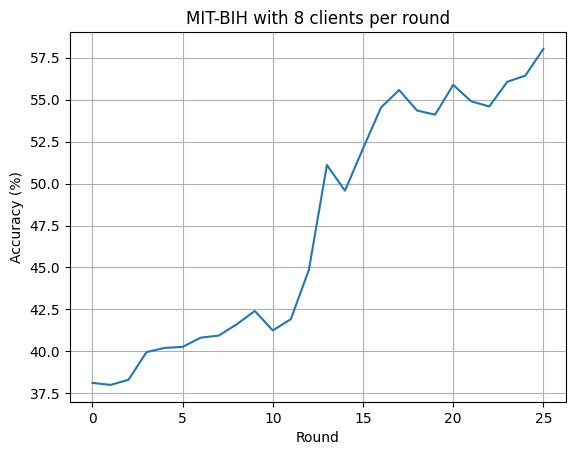

In [ ]:
print(f"{history.metrics_centralized = }")

global_accuracy_centralised = history.metrics_centralized["accuracy"]
round = [data[0] for data in global_accuracy_centralised]
acc = [100.0 * data[1] for data in global_accuracy_centralised]
plt.plot(round, acc)
plt.grid()
plt.ylabel("Accuracy (%)")
plt.xlabel("Round")
plt.title("MIT-BIH with 8 clients per round")

In [ ]:
person = "Bharghav"
print(f"hello {person}")

hello Bharghav
